In [1]:
# ============================================================
# CELL 1 — INSTALL, IMPORT, LOAD, AND BUILD YOUTUBE BENCHMARK
# ============================================================

# ------------------------------------------------------------
# 0. Install required packages
# ------------------------------------------------------------

!pip uninstall -y community -q

!pip install -q \
    numpy \
    pandas \
    networkx \
    scikit-learn \
    tqdm \
    python-louvain \
    GraphRicciCurvature \
    scipy \
    igraph \
    leidenalg \
    jinja2


# ------------------------------------------------------------
# 1. Imports and configuration
# ------------------------------------------------------------

import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

import community_detection_utils as cdu


RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATASET_NAME = "YouTube"


# ------------------------------------------------------------
# 2. Data paths and URLs
# ------------------------------------------------------------

DATA_DIR = Path("./data/youtube")

DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EDGES_FILE = (
    DATA_DIR
    / "com-youtube.ungraph.txt.gz"
)

CMTY_FILE = (
    DATA_DIR
    / "com-youtube.top5000.cmty.txt.gz"
)

EDGE_URL = (
    "https://snap.stanford.edu/data/bigdata/"
    "communities/com-youtube.ungraph.txt.gz"
)

CMTY_URL = (
    "https://snap.stanford.edu/data/bigdata/"
    "communities/com-youtube.top5000.cmty.txt.gz"
)


# ------------------------------------------------------------
# 3. Community-selection settings
# ------------------------------------------------------------

MIN_COMMUNITY_SIZE = 20
MAX_COMMUNITY_SIZE = 500

COND_MIN = 0.05
COND_MAX = 0.95

N_COMMUNITIES = 25


# ------------------------------------------------------------
# 4. Curvature settings
# ------------------------------------------------------------

LRC_ONLY_PCT = 10

LRC_COMBO_PCT = 2
ORC_COMBO_PCT = 2

ALPHA = 0.5
ORC_ITERATIONS = 5

SEEDS = [
    0,
    1,
    2,
    3,
    4,
    42,
]


# ------------------------------------------------------------
# 5. Download the data
# ------------------------------------------------------------

cdu.download_if_missing(
    EDGE_URL,
    EDGES_FILE,
)

cdu.download_if_missing(
    CMTY_URL,
    CMTY_FILE,
)


# ------------------------------------------------------------
# 6. Load full YouTube graph
# ------------------------------------------------------------

G_full = nx.Graph()

for chunk in tqdm(
    cdu.stream_edges(EDGES_FILE),
    desc="Loading YouTube graph",
):

    G_full.add_edges_from(
        chunk[
            [
                "u",
                "v",
            ]
        ].itertuples(
            index=False,
            name=None,
        )
    )


G_full.remove_edges_from(
    nx.selfloop_edges(G_full)
)


# ------------------------------------------------------------
# 7. Load YouTube communities
# ------------------------------------------------------------

communities = cdu.load_communities(
    CMTY_FILE,
    min_size=1,
)


print(G_full)

print(
    "Total communities:",
    len(communities),
)

print(
    "Connected components:",
    nx.number_connected_components(
        G_full
    ),
)

print(
    "Largest component size:",
    len(
        max(
            nx.connected_components(
                G_full
            ),
            key=len,
        )
    ),
)


print(
    "\nCommunity-size distribution:"
)

display(
    pd.Series(
        [
            len(community)
            for community in communities
        ]
    ).describe()
)


# ------------------------------------------------------------
# 8. Compute structural metrics for all communities
# ------------------------------------------------------------

community_metric_rows = []

for cid, nodes in tqdm(
    list(
        enumerate(
            communities
        )
    ),
    desc="Computing YouTube community metrics",
):

    metrics = cdu.compute_community_metrics(
        G_full,
        nodes,
    )

    if metrics is not None:

        metrics[
            "community_id"
        ] = cid

        community_metric_rows.append(
            metrics
        )


metric_df = pd.DataFrame(
    community_metric_rows
)

metric_df = metric_df[
    np.isfinite(
        metric_df[
            "conductance"
        ]
    )
].copy()


print(
    "Communities with finite conductance:",
    len(metric_df),
)


# ------------------------------------------------------------
# 9. Filter candidate communities
# ------------------------------------------------------------

candidate_df = metric_df[
    (
        metric_df[
            "size"
        ]
        >= MIN_COMMUNITY_SIZE
    )
    &
    (
        metric_df[
            "size"
        ]
        <= MAX_COMMUNITY_SIZE
    )
    &
    (
        metric_df[
            "conductance"
        ]
        >= COND_MIN
    )
    &
    (
        metric_df[
            "conductance"
        ]
        <= COND_MAX
    )
].copy()


print(
    "Candidate communities:",
    len(candidate_df),
)

display(
    candidate_df.describe()
)


# ------------------------------------------------------------
# 10. Select communities reproducibly
# ------------------------------------------------------------

if len(candidate_df) < N_COMMUNITIES:

    print(
        "Fewer candidate communities than requested. "
        "Using all available candidates."
    )

    N_SELECTED = len(
        candidate_df
    )

else:

    N_SELECTED = N_COMMUNITIES


if N_SELECTED == 0:

    raise ValueError(
        "No candidate communities were found. "
        "Relax the size or conductance filters."
    )


rng = np.random.default_rng(
    RANDOM_SEED
)

picked_ids = rng.choice(
    candidate_df[
        "community_id"
    ].tolist(),
    size=N_SELECTED,
    replace=False,
).tolist()

picked_ids = sorted(
    picked_ids
)


selected_df = candidate_df[
    candidate_df[
        "community_id"
    ].isin(
        picked_ids
    )
].copy()


print(
    "Selected communities:",
    len(selected_df),
)

display(
    selected_df[
        [
            "community_id",
            "size",
            "conductance",
            "BTD",
            "internal_edges",
            "boundary_edges",
        ]
    ]
)


# ------------------------------------------------------------
# 11. Build node-to-community membership map
# ------------------------------------------------------------

node_to_cids = defaultdict(
    list
)

for cid in picked_ids:

    for node in communities[
        cid
    ]:

        if node in G_full:

            node_to_cids[
                node
            ].append(
                cid
            )


nodes_of_interest = set(
    node_to_cids.keys()
)


# ------------------------------------------------------------
# 12. Build induced benchmark graph
# ------------------------------------------------------------

H_raw = G_full.subgraph(
    nodes_of_interest
).copy()


print(
    "\nBefore GCC:"
)

print(
    "Nodes:",
    H_raw.number_of_nodes(),
)

print(
    "Edges:",
    H_raw.number_of_edges(),
)

print(
    "Components:",
    (
        nx.number_connected_components(
            H_raw
        )
        if H_raw.number_of_nodes() > 0
        else 0
    ),
)


# ------------------------------------------------------------
# 13. Retain Giant Connected Component
# ------------------------------------------------------------

H = cdu.get_gcc(
    H_raw
)


print(
    "\nAfter GCC:"
)

print(
    "Nodes:",
    H.number_of_nodes(),
)

print(
    "Edges:",
    H.number_of_edges(),
)

print(
    "Components:",
    (
        nx.number_connected_components(
            H
        )
        if H.number_of_nodes() > 0
        else 0
    ),
)


# ------------------------------------------------------------
# 14. Assign one ground-truth label to each node
# ------------------------------------------------------------

cid_to_label = {
    cid: label
    for label, cid in enumerate(
        picked_ids
    )
}

community_size = {
    cid: len(
        communities[
            cid
        ]
    )
    for cid in picked_ids
}


for node in H.nodes():

    node_cids = node_to_cids.get(
        node,
        [],
    )

    if len(node_cids) == 0:
        continue

    # For overlapping nodes, assign the smallest selected
    # community. This preserves the original notebook rule.

    best_cid = min(
        node_cids,
        key=lambda cid: community_size[
            cid
        ],
    )

    H.nodes[
        node
    ][
        "label_gt"
    ] = cid_to_label[
        best_cid
    ]

    H.nodes[
        node
    ][
        "original_cids"
    ] = node_cids

    H.nodes[
        node
    ][
        "is_overlap"
    ] = int(
        len(node_cids) > 1
    )


# ------------------------------------------------------------
# 15. Validate benchmark labels
# ------------------------------------------------------------

EVAL_NODES = [
    node
    for node in H.nodes()
    if "label_gt"
    in H.nodes[node]
]

labels = [
    H.nodes[
        node
    ][
        "label_gt"
    ]
    for node in EVAL_NODES
]


print(
    "\nLabeled nodes:",
    len(labels),
)

print(
    "Number of labels:",
    len(
        set(labels)
    ),
)

print(
    "Overlap fraction:",
    (
        np.mean(
            [
                H.nodes[
                    node
                ].get(
                    "is_overlap",
                    0,
                )
                for node in EVAL_NODES
            ]
        )
        if EVAL_NODES
        else np.nan
    ),
)


print(
    "\nGround-truth label sizes:"
)

display(
    pd.Series(
        labels
    )
    .value_counts()
    .sort_values(
        ascending=False
    )
)


print(
    f"\nFinal YouTube benchmark: "
    f"|V|={H.number_of_nodes():,}, "
    f"|E|={H.number_of_edges():,}"
)


# ------------------------------------------------------------
# 16. Basic validation
# ------------------------------------------------------------

assert H.number_of_nodes() > 0
assert H.number_of_edges() > 0
assert nx.is_connected(H)
assert len(EVAL_NODES) > 0
assert len(set(labels)) >= 2

print(
    "\nYouTube benchmark construction completed successfully."
)

Already exists: data/youtube/com-youtube.ungraph.txt.gz
Already exists: data/youtube/com-youtube.top5000.cmty.txt.gz


Loading YouTube graph: 3it [00:07,  2.41s/it]


Graph with 1134890 nodes and 2987624 edges
Total communities: 5000
Connected components: 1
Largest component size: 1134890

Community-size distribution:


count    5000.00000
mean       14.59180
std        60.45619
min         2.00000
25%         2.00000
50%         4.00000
75%        10.00000
max      2217.00000
dtype: float64

Computing YouTube community metrics: 100%|██████████| 5000/5000 [00:38<00:00, 129.91it/s] 

...

Selected communities: 25


,community_id,size,conductance,BTD,internal_edges,boundary_edges
281,281,467,0.915933,11.085861,1581,34451
282,282,38,0.867380,2.163995,62,811
286,286,64,0.875483,3.015436,129,1814
364,364,67,0.928728,10.799899,228,5942
467,467,21,0.948655,2.461340,21,776
508,508,119,0.891268,5.108210,292,4787
930,930,42,0.937402,6.074012,60,1797
1039,1039,102,0.627100,1.508211,344,1157
1049,1049,166,0.931813,3.680049,329,8992
1091,1091,43,0.933047,5.401104,78,2174



Before GCC:
Nodes: 1846
Edges: 5747
Components: 3

After GCC:
Nodes: 1760
Edges: 5600
Components: 1

Labeled nodes: 1760
Number of labels: 23
Overlap fraction: 0.019318181818181818

Ground-truth label sizes:


0     443
19    197
8     166
5     116
7     101
15     90
3      67
2      63
14     59
24     57
13     49
20     44
6      42
9      41
12     32
17     31
10     30
16     24
18     23
23     23
4      21
11     21
21     20
Name: count, dtype: int64


Final YouTube benchmark: |V|=1,760, |E|=5,600

YouTube benchmark construction completed successfully.


In [2]:
# ============================================================
# LRC-ORC-ONLY TIMING EVALUATOR
# Community detection is evaluated but excluded from runtime.
# ============================================================

def evaluate_prepared_graph_lrc_orc_only(
    info,
    algorithm="louvain",
    seed=42,
    weight="weight",
    label_attribute="label_gt",
):

    graph = info["graph"]
    algorithm_lower = algorithm.lower()

    if algorithm_lower == "louvain":
        partition = cdu.run_louvain(
            graph,
            weight=weight,
            seed=seed,
        )
        method_name = info["method_base"]

    elif algorithm_lower == "leiden":
        partition = cdu.run_leiden(
            graph,
            weight=weight,
            seed=seed,
        )
        method_name = info["method_base"] + " + Leiden"

    else:
        raise ValueError(
            "algorithm must be 'louvain' or 'leiden'."
        )

    ari, nmi, n_eval = cdu.eval_partition(
        graph,
        partition,
        label_attribute=label_attribute,
    )

    return {
        "method": method_name,
        "algorithm": algorithm_lower,
        "seed": seed,
        "ARI": ari,
        "NMI": nmi,
        "n_eval": n_eval,
        "V": graph.number_of_nodes(),
        "E": graph.number_of_edges(),
        "components": (
            nx.number_connected_components(graph)
            if graph.number_of_nodes() > 0
            else 0
        ),
        "runtime_sec": info["prep_time"],
        "prep_time": info["prep_time"],
        "community_time": 0.0,
        "removed_lrc": info["removed_lrc"],
        "removed_orc": info["removed_orc"],
        "pct_lrc": info["pct_lrc"],
        "pct_orc": info["pct_orc"],
        "alpha": info["alpha"],
        "iterations": info["iterations"],
        "cutoff_lrc": info["cutoff_lrc"],
        "cutoff_orc": info["cutoff_orc"],
    }


cdu.evaluate_prepared_graph = evaluate_prepared_graph_lrc_orc_only

In [3]:
# ============================================================
# YOUTUBE OUTPUT DIRECTORY
# ============================================================

import os

if Path.cwd().name == "youtube_data_output":
    YOUTUBE_OUTPUT_DIR = Path.cwd()
else:
    YOUTUBE_OUTPUT_DIR = (
        Path.cwd()
        / "notebook_output_data"
        / "youtube_data_output"
    )

YOUTUBE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

os.chdir(YOUTUBE_OUTPUT_DIR)

print(
    f"YouTube outputs will be saved under: {YOUTUBE_OUTPUT_DIR}"
)

YouTube outputs will be saved under: /home/josejgarcia/Documents/Git_Hub_Repos/community-detection/notebook_output_data/youtube_data_output


In [4]:
# ============================================================
# CELL 2 — PREPARE YOUTUBE LRC, ORC, AND COMBO GRAPHS
# ============================================================

print(
    f"Input YouTube benchmark: "
    f"|V|={H.number_of_nodes():,}, "
    f"|E|={H.number_of_edges():,}"
)


# ============================================================
# 1. PREPARE LRC-ONLY GRAPH
# ============================================================

lrc_info = cdu.prepare_lrc_graph(
    graph=H,
    lrc_pct=LRC_ONLY_PCT,
    print_distribution=True,
)

G_lrc = lrc_info[
    "graph"
]


print(
    "\n" + "=" * 65
)

print(
    "LRC-only graph prepared"
)

print(
    "=" * 65
)

print(
    f"Output graph: "
    f"|V|={G_lrc.number_of_nodes():,}, "
    f"|E|={G_lrc.number_of_edges():,}"
)

print(
    "Removed LRC edges:",
    lrc_info[
        "removed_lrc"
    ],
)

print(
    "LRC cutoff:",
    lrc_info[
        "cutoff_lrc"
    ],
)

print(
    "Preparation time:",
    f"{lrc_info['prep_time']:.2f} seconds",
)


# ============================================================
# 2. PREPARE ORC-ONLY GRAPH
# ============================================================

orc_info = cdu.prepare_orc_graph(
    graph=H,
    alpha=ALPHA,
    iterations=ORC_ITERATIONS,
    method="Sinkhorn",
)

G_orc = orc_info[
    "graph"
]


print(
    "\n" + "=" * 65
)

print(
    "ORC-only graph prepared"
)

print(
    "=" * 65
)

print(
    f"Output graph: "
    f"|V|={G_orc.number_of_nodes():,}, "
    f"|E|={G_orc.number_of_edges():,}"
)

print(
    "Alpha:",
    orc_info[
        "alpha"
    ],
)

print(
    "Ricci-flow iterations:",
    orc_info[
        "iterations"
    ],
)

print(
    "Preparation time:",
    f"{orc_info['prep_time']:.2f} seconds",
)


# ============================================================
# 3. PREPARE LRC → ORC COMBO GRAPH
# ============================================================

combo_info = cdu.prepare_combo_graph(
    graph=H,
    lrc_pct=LRC_COMBO_PCT,
    orc_pct=ORC_COMBO_PCT,
    alpha=ALPHA,
    iterations=ORC_ITERATIONS,
    method="Sinkhorn",
)

G_combo = combo_info[
    "graph"
]


print(
    "\n" + "=" * 65
)

print(
    "LRC → ORC combo graph prepared"
)

print(
    "=" * 65
)

print(
    f"Output graph: "
    f"|V|={G_combo.number_of_nodes():,}, "
    f"|E|={G_combo.number_of_edges():,}"
)

print(
    "Removed during LRC pruning:",
    combo_info[
        "removed_lrc"
    ],
)

print(
    "Removed during ORC pruning:",
    combo_info[
        "removed_orc"
    ],
)

print(
    "LRC cutoff:",
    combo_info[
        "cutoff_lrc"
    ],
)

print(
    "ORC cutoff:",
    combo_info[
        "cutoff_orc"
    ],
)

print(
    "Preparation time:",
    f"{combo_info['prep_time']:.2f} seconds",
)


# ============================================================
# 4. GRAPH-REDUCTION SUMMARY
# ============================================================

input_nodes = H.number_of_nodes()
input_edges = H.number_of_edges()


prepared_graph_summary = pd.DataFrame(
    [
        {
            "Method": "LRC-only",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": (
                G_lrc.number_of_nodes()
            ),
            "Output Edges": (
                G_lrc.number_of_edges()
            ),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_lrc.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_lrc.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                lrc_info[
                    "prep_time"
                ]
            ),
        },
        {
            "Method": "ORC-only",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": (
                G_orc.number_of_nodes()
            ),
            "Output Edges": (
                G_orc.number_of_edges()
            ),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_orc.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_orc.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                orc_info[
                    "prep_time"
                ]
            ),
        },
        {
            "Method": "LRC→ORC combo",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": (
                G_combo.number_of_nodes()
            ),
            "Output Edges": (
                G_combo.number_of_edges()
            ),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_combo.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_combo.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                combo_info[
                    "prep_time"
                ]
            ),
        },
    ]
)


prepared_graph_summary[
    [
        "Node Reduction (%)",
        "Edge Reduction (%)",
        "Preparation Time (s)",
    ]
] = prepared_graph_summary[
    [
        "Node Reduction (%)",
        "Edge Reduction (%)",
        "Preparation Time (s)",
    ]
].round(2)


print(
    "\nPrepared YouTube graph summary:"
)

display(
    prepared_graph_summary
)


# ============================================================
# 5. VALIDATION CHECKS
# ============================================================

assert G_lrc.number_of_nodes() > 0
assert G_lrc.number_of_edges() > 0

assert G_orc.number_of_nodes() > 0
assert G_orc.number_of_edges() > 0

assert G_combo.number_of_nodes() > 0
assert G_combo.number_of_edges() > 0

assert nx.is_connected(
    G_lrc
)

assert nx.is_connected(
    G_orc
)

assert nx.is_connected(
    G_combo
)


print(
    "\nAll prepared YouTube graphs are "
    "non-empty and connected."
)

Input YouTube benchmark: |V|=1,760, |E|=5,600
LRC distribution:
count    5600.000000
mean       -0.897787
std         0.583006
min        -1.925285
25%        -1.360902
50%        -0.983312
75%        -0.500000
max         1.500000
dtype: float64

LRC-only graph prepared
Output graph: |V|=1,760, |E|=5,038
Removed LRC edges: 562
LRC cutoff: -1.5777777777777777
Preparation time: 0.07 seconds

ORC-only graph prepared
Output graph: |V|=1,760, |E|=5,600
Alpha: 0.5
Ricci-flow iterations: 5
Preparation time: 16.62 seconds

LRC → ORC combo graph prepared
Output graph: |V|=1,759, |E|=5,378
Removed during LRC pruning: 112
Removed during ORC pruning: 110
LRC cutoff: -1.749041067041067
ORC cutoff: -0.30256088655103774
Preparation time: 16.16 seconds

Prepared YouTube graph summary:


,Method,Input Nodes,Input Edges,Output Nodes,Output Edges,Node Reduction (%),Edge Reduction (%),Preparation Time (s)
0,LRC-only,1760,5600,1760,5038,0.00,10.04,0.07
1,ORC-only,1760,5600,1760,5600,0.00,0.00,16.62
2,LRC→ORC combo,1760,5600,1759,5378,0.06,3.96,16.16



All prepared YouTube graphs are non-empty and connected.


In [5]:
# ============================================================
# CELL 3 — YOUTUBE MULTI-SEED EVALUATION AND RESULT TABLES
# ============================================================

prepared = [
    lrc_info,
    orc_info,
    combo_info,
]


# ============================================================
# 1. SINGLE-SEED RESULTS
# ============================================================

single_seed_rows = []


single_seed_rows.append(
    cdu.evaluate_plain_graph(
        graph=H,
        algorithm="louvain",
        seed=RANDOM_SEED,
    )
)


single_seed_rows.append(
    cdu.evaluate_plain_graph(
        graph=H,
        algorithm="leiden",
        seed=RANDOM_SEED,
    )
)


for info in prepared:

    single_seed_rows.append(
        cdu.evaluate_prepared_graph(
            info=info,
            algorithm="louvain",
            seed=RANDOM_SEED,
        )
    )

    single_seed_rows.append(
        cdu.evaluate_prepared_graph(
            info=info,
            algorithm="leiden",
            seed=RANDOM_SEED,
        )
    )


df_single_seed = pd.DataFrame(
    single_seed_rows
)


print(
    f"YouTube single-seed results "
    f"(seed={RANDOM_SEED}):"
)

display(
    df_single_seed[
        [
            "method",
            "algorithm",
            "seed",
            "ARI",
            "NMI",
            "n_eval",
            "V",
            "E",
            "runtime_sec",
            "prep_time",
            "community_time",
            "removed_lrc",
            "removed_orc",
        ]
    ].sort_values(
        "ARI",
        ascending=False,
    )
)


df_single_seed.to_csv(
    "youtube_single_seed_results.csv",
    index=False,
)


# ============================================================
# 2. MULTI-SEED EVALUATION
# ============================================================

multi_rows = []


for seed in SEEDS:

    print(
        "\n" + "=" * 70
    )

    print(
        "Seed:",
        seed,
    )

    print(
        "=" * 70
    )


    # --------------------------------------------------------
    # Plain Louvain
    # --------------------------------------------------------

    plain_louvain = (
        cdu.evaluate_plain_graph(
            graph=H,
            algorithm="louvain",
            seed=seed,
        )
    )

    multi_rows.append(
        plain_louvain
    )

    print(
        f"{plain_louvain['method']}: "
        f"ARI={plain_louvain['ARI']:.4f}, "
        f"NMI={plain_louvain['NMI']:.4f}, "
        f"Runtime={plain_louvain['runtime_sec']:.2f}s"
    )


    # --------------------------------------------------------
    # Plain Leiden
    # --------------------------------------------------------

    plain_leiden = (
        cdu.evaluate_plain_graph(
            graph=H,
            algorithm="leiden",
            seed=seed,
        )
    )

    multi_rows.append(
        plain_leiden
    )

    print(
        f"{plain_leiden['method']}: "
        f"ARI={plain_leiden['ARI']:.4f}, "
        f"NMI={plain_leiden['NMI']:.4f}, "
        f"Runtime={plain_leiden['runtime_sec']:.2f}s"
    )


    # --------------------------------------------------------
    # Curvature methods with Louvain
    # --------------------------------------------------------

    for info in prepared:

        result = (
            cdu.evaluate_prepared_graph(
                info=info,
                algorithm="louvain",
                seed=seed,
            )
        )

        multi_rows.append(
            result
        )

        print(
            f"{result['method']}: "
            f"ARI={result['ARI']:.4f}, "
            f"NMI={result['NMI']:.4f}, "
            f"Runtime={result['runtime_sec']:.2f}s"
        )


    # --------------------------------------------------------
    # Curvature methods with Leiden
    # --------------------------------------------------------

    for info in prepared:

        result = (
            cdu.evaluate_prepared_graph(
                info=info,
                algorithm="leiden",
                seed=seed,
            )
        )

        multi_rows.append(
            result
        )

        print(
            f"{result['method']}: "
            f"ARI={result['ARI']:.4f}, "
            f"NMI={result['NMI']:.4f}, "
            f"Runtime={result['runtime_sec']:.2f}s"
        )


# ============================================================
# 3. COMPLETE MULTI-SEED DATAFRAME
# ============================================================

df_multi = pd.DataFrame(
    multi_rows
)


expected_rows = (
    len(SEEDS) * 8
)


print(
    "\nMulti-seed dataframe shape:",
    df_multi.shape,
)


assert len(df_multi) == expected_rows, (
    f"Expected {expected_rows} rows, "
    f"but found {len(df_multi)}."
)


display(
    df_multi[
        [
            "method",
            "algorithm",
            "seed",
            "ARI",
            "NMI",
            "n_eval",
            "V",
            "E",
            "runtime_sec",
            "prep_time",
            "community_time",
            "removed_lrc",
            "removed_orc",
        ]
    ].sort_values(
        [
            "seed",
            "method",
        ]
    )
)


df_multi.to_csv(
    "youtube_multiseed_results.csv",
    index=False,
)


# ============================================================
# 4. NUMERIC SUMMARY
# ============================================================

numeric_summary = (
    df_multi
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        ARI_mean=(
            "ARI",
            "mean",
        ),
        ARI_std=(
            "ARI",
            "std",
        ),
        NMI_mean=(
            "NMI",
            "mean",
        ),
        NMI_std=(
            "NMI",
            "std",
        ),
        Runtime_mean=(
            "runtime_sec",
            "mean",
        ),
        Runtime_std=(
            "runtime_sec",
            "std",
        ),
        n_eval_mean=(
            "n_eval",
            "mean",
        ),
        Output_Nodes=(
            "V",
            "mean",
        ),
        Output_Edges=(
            "E",
            "mean",
        ),
        Prep_Time_mean=(
            "prep_time",
            "mean",
        ),
        Community_Time_mean=(
            "community_time",
            "mean",
        ),
    )
    .sort_values(
        "ARI_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nYouTube numeric summary:"
)

display(
    numeric_summary
)


numeric_summary.to_csv(
    "youtube_numeric_summary.csv",
    index=False,
)


# ============================================================
# 5. PAPER-STYLE MEAN ± STD TABLE
# ============================================================

paper_table = numeric_summary.copy()


paper_table["ARI"] = (
    paper_table[
        "ARI_mean"
    ].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + paper_table[
        "ARI_std"
    ].map(
        lambda value: f"{value:.3f}"
    )
)


paper_table["NMI"] = (
    paper_table[
        "NMI_mean"
    ].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + paper_table[
        "NMI_std"
    ].map(
        lambda value: f"{value:.3f}"
    )
)


paper_table["Runtime (s)"] = (
    paper_table[
        "Runtime_mean"
    ].map(
        lambda value: f"{value:.2f}"
    )
    + " ± "
    + paper_table[
        "Runtime_std"
    ].map(
        lambda value: f"{value:.2f}"
    )
)


paper_table["Input Nodes"] = (
    H.number_of_nodes()
)

paper_table["Input Edges"] = (
    H.number_of_edges()
)

paper_table["Output Nodes"] = (
    paper_table[
        "Output_Nodes"
    ]
    .round()
    .astype(int)
)

paper_table["Output Edges"] = (
    paper_table[
        "Output_Edges"
    ]
    .round()
    .astype(int)
)


paper_table["Edge Reduction (%)"] = (
    100
    * (
        1
        - paper_table[
            "Output Edges"
        ]
        / H.number_of_edges()
    )
).round(2)


paper_table = paper_table[
    [
        "method",
        "ARI",
        "NMI",
        "Runtime (s)",
        "Input Nodes",
        "Input Edges",
        "Output Nodes",
        "Output Edges",
        "Edge Reduction (%)",
    ]
].rename(
    columns={
        "method": "Method",
    }
)


print(
    "\nYouTube paper-style table:"
)

display(
    paper_table
)


paper_table.to_csv(
    "youtube_final_mean_std_table.csv",
    index=False,
)


# ============================================================
# 6. THREE-METHOD MAIN-PAPER TABLE
# ============================================================

main_methods = [
    "LRC-only",
    "ORC-only",
    "LRC→ORC combo",
]


main_paper_table = (
    paper_table[
        paper_table[
            "Method"
        ].isin(
            main_methods
        )
    ]
    .copy()
)


main_paper_table["Method"] = (
    pd.Categorical(
        main_paper_table[
            "Method"
        ],
        categories=main_methods,
        ordered=True,
    )
)


main_paper_table = (
    main_paper_table
    .sort_values(
        "Method"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nThree-method YouTube table "
    "for the main article:"
)

display(
    main_paper_table
)


main_paper_table.to_csv(
    "youtube_main_three_method_table.csv",
    index=False,
)


# ============================================================
# 7. PAIRED STATISTICAL TESTS
# ============================================================

ari_tests_vs_orc = (
    cdu.paired_tests(
        results=df_multi,
        baseline_method="ORC-only",
        metric="ARI",
    )
)


nmi_tests_vs_orc = (
    cdu.paired_tests(
        results=df_multi,
        baseline_method="ORC-only",
        metric="NMI",
    )
)


print(
    "\nPaired ARI tests against ORC-only:"
)

display(
    ari_tests_vs_orc
)


print(
    "\nPaired NMI tests against ORC-only:"
)

display(
    nmi_tests_vs_orc
)


ari_tests_vs_orc.to_csv(
    "youtube_ari_paired_tests_vs_orc.csv",
    index=False,
)


nmi_tests_vs_orc.to_csv(
    "youtube_nmi_paired_tests_vs_orc.csv",
    index=False,
)


# ============================================================
# 8. LATEX EXPORT
# ============================================================

latex_table = (
    main_paper_table.to_latex(
        index=False,
        escape=False,
        caption=(
            "Community detection results on the YouTube "
            "benchmark, reported as mean "
            "$\\pm$ standard deviation across random seeds."
        ),
        label="tab:youtube_results",
    )
)


print(
    "\nYouTube LaTeX table:"
)

print(
    latex_table
)


with open(
    "youtube_main_three_method_table.tex",
    "w",
    encoding="utf-8",
) as file:

    file.write(
        latex_table
    )

YouTube single-seed results (seed=42):


,method,algorithm,seed,ARI,NMI,n_eval,V,E,runtime_sec,prep_time,community_time,removed_lrc,removed_orc
1,Plain Leiden,leiden,42,0.727048,0.820775,1760,1760,5600,0.036799,0.000000,0.036799,0,0
3,LRC-only + Leiden,leiden,42,0.705227,0.814842,1760,1760,5038,0.068732,0.068732,0.000000,562,0
2,LRC-only,louvain,42,0.684447,0.803500,1760,1760,5038,0.068732,0.068732,0.000000,562,0
5,ORC-only + Leiden,leiden,42,0.658043,0.772883,1760,1760,5600,16.622433,16.622433,0.000000,0,0
7,LRC→ORC combo + Leiden,leiden,42,0.655196,0.769473,1759,1759,5378,16.155635,16.155635,0.000000,112,110
0,Plain Louvain,louvain,42,0.654077,0.791171,1760,1760,5600,0.185665,0.000000,0.185665,0,0
6,LRC→ORC combo,louvain,42,0.632857,0.760196,1759,1759,5378,16.155635,16.155635,0.000000,112,110
4,ORC-only,louvain,42,0.613047,0.743684,1760,1760,5600,16.622433,16.622433,0.000000,0,0



Seed: 0
Plain Louvain: ARI=0.6501, NMI=0.7879, Runtime=0.11s
Plain Leiden: ARI=0.7173, NMI=0.8141, Runtime=0.03s
LRC-only: ARI=0.7168, NMI=0.8056, Runtime=0.07s
ORC-only: ARI=0.6207, NMI=0.7548, Runtime=16.62s
LRC→ORC combo: ARI=0.5718, NMI=0.7273, Runtime=16.16s
LRC-only + Leiden: ARI=0.6878, NMI=0.8055, Runtime=0.07s
ORC-only + Leiden: ARI=0.6848, NMI=0.7837, Runtime=16.62s
LRC→ORC combo + Leiden: ARI=0.6570, NMI=0.7744, Runtime=16.16s

Seed: 1
Plain Louvain: ARI=0.6788, NMI=0.7863, Runtime=0.11s
Plain Leiden: ARI=0.7013, NMI=0.8051, Runtime=0.03s
LRC-only: ARI=0.6941, NMI=0.8001, Runtime=0.07s
ORC-only: ARI=0.6149, NMI=0.7434, Runtime=16.62s
LRC→ORC combo: ARI=0.6261, NMI=0.7489, Runtime=16.16s
LRC-only + Leiden: ARI=0.7145, NMI=0.8174, Runtime=0.07s
ORC-only + Leiden: ARI=0.6430, NMI=0.7612, Runtime=16.62s
LRC→ORC combo + Leiden: ARI=0.6687, NMI=0.7653, Runtime=16.16s

Seed: 2
Plain Louvain: ARI=0.6684, NMI=0.7963, Runtime=0.12s
Plain Leiden: ARI=0.6841, NMI=0.7975, Runtime=0.03s


,method,algorithm,seed,ARI,NMI,n_eval,V,E,runtime_sec,prep_time,community_time,removed_lrc,removed_orc
2,LRC-only,louvain,0,0.716786,0.805577,1760,1760,5038,0.068732,0.068732,0.000000,562,0
5,LRC-only + Leiden,leiden,0,0.687796,0.805524,1760,1760,5038,0.068732,0.068732,0.000000,562,0
4,LRC→ORC combo,louvain,0,0.571816,0.727264,1759,1759,5378,16.155635,16.155635,0.000000,112,110
7,LRC→ORC combo + Leiden,leiden,0,0.657049,0.774441,1759,1759,5378,16.155635,16.155635,0.000000,112,110
3,ORC-only,louvain,0,0.620668,0.754840,1760,1760,5600,16.622433,16.622433,0.000000,0,0
6,ORC-only + Leiden,leiden,0,0.684752,0.783731,1760,1760,5600,16.622433,16.622433,0.000000,0,0
1,Plain Leiden,leiden,0,0.717347,0.814120,1760,1760,5600,0.034151,0.000000,0.034151,0,0
0,Plain Louvain,louvain,0,0.650095,0.787862,1760,1760,5600,0.113077,0.000000,0.113077,0,0
10,LRC-only,louvain,1,0.694146,0.800108,1760,1760,5038,0.068732,0.068732,0.000000,562,0
13,LRC-only + Leiden,leiden,1,0.714520,0.817450,1760,1760,5038,0.068732,0.068732,0.000000,562,0



YouTube numeric summary:


...


Paired ARI tests against ORC-only:


,baseline,method,metric,n_pairs,baseline_mean,method_mean,mean_diff,paired_t_p,wilcoxon_p
0,ORC-only,LRC-only,ARI,6,0.595391,0.692291,0.096900,0.000060,0.03125
1,ORC-only,LRC-only + Leiden,ARI,6,0.595391,0.705754,0.110363,0.000236,0.03125
2,ORC-only,LRC→ORC combo,ARI,6,0.595391,0.620907,0.025516,0.215011,0.21875
3,ORC-only,LRC→ORC combo + Leiden,ARI,6,0.595391,0.659733,0.064342,0.001197,0.03125
4,ORC-only,ORC-only + Leiden,ARI,6,0.595391,0.654019,0.058628,0.000752,0.03125
5,ORC-only,Plain Leiden,ARI,6,0.595391,0.704654,0.109263,0.000025,0.03125
6,ORC-only,Plain Louvain,ARI,6,0.595391,0.660907,0.065516,0.002197,0.03125



Paired NMI tests against ORC-only:


,baseline,method,metric,n_pairs,baseline_mean,method_mean,mean_diff,paired_t_p,wilcoxon_p
0,ORC-only,LRC-only,NMI,6,0.732087,0.798867,0.066780,0.000113,0.03125
1,ORC-only,LRC-only + Leiden,NMI,6,0.732087,0.812174,0.080087,0.000123,0.03125
2,ORC-only,LRC→ORC combo,NMI,6,0.732087,0.751429,0.019342,0.170788,0.21875
3,ORC-only,LRC→ORC combo + Leiden,NMI,6,0.732087,0.773593,0.041505,0.005681,0.03125
4,ORC-only,ORC-only + Leiden,NMI,6,0.732087,0.768453,0.036366,0.002228,0.03125
5,ORC-only,Plain Leiden,NMI,6,0.732087,0.808503,0.076416,0.000032,0.03125
6,ORC-only,Plain Louvain,NMI,6,0.732087,0.786602,0.054515,0.000802,0.03125



YouTube LaTeX table:
\begin{table}
\caption{Community detection results on the YouTube benchmark, reported as mean $\pm$ standard deviation across random seeds.}
\label{tab:youtube_results}
\begin{tabular}{llllrrrrr}
\toprule
Method & ARI & NMI & Runtime (s) & Input Nodes & Input Edges & Output Nodes & Output Edges & Edge Reduction (%) \\
\midrule
LRC-only & 0.692 ± 0.013 & 0.799 ± 0.006 & 0.07 ± 0.00 & 1760 & 5600 & 1760 & 5038 & 10.040000 \\
ORC-only & 0.595 ± 0.024 & 0.732 ± 0.018 & 16.62 ± 0.00 & 1760 & 5600 & 1760 & 5600 & 0.000000 \\
LRC→ORC combo & 0.621 ± 0.026 & 0.751 ± 0.014 & 16.16 ± 0.00 & 1760 & 5600 & 1759 & 5378 & 3.960000 \\
\bottomrule
\end{tabular}
\end{table}



In [6]:
# ============================================================
# CELL 4 — STRUCTURAL ANALYSIS OF THE YOUTUBE BENCHMARK
# ============================================================

# ============================================================
# 1. BASIC GRAPH STATISTICS
# ============================================================

basic_stats = pd.DataFrame(
    [
        cdu.basic_graph_stats(
            graph=H,
            dataset_name="YouTube",
            include_path_metrics=True,
        )
    ]
)


print(
    "Basic YouTube graph statistics:"
)

display(
    basic_stats
)


basic_stats.to_csv(
    "youtube_basic_graph_stats.csv",
    index=False,
)


# ============================================================
# 2. GROUND-TRUTH LABEL STATISTICS
# ============================================================

label_stats_dict, label_counts = (
    cdu.label_structure_stats(
        graph=H,
        label_attribute="label_gt",
        overlap_attribute="is_overlap",
    )
)


label_stats = pd.DataFrame(
    [
        label_stats_dict
    ]
)


print(
    "\nGround-truth label statistics:"
)

display(
    label_stats
)


print(
    "\nGround-truth label sizes:"
)


label_size_table = (
    label_counts
    .sort_values(
        ascending=False
    )
    .rename(
        "Community Size"
    )
    .to_frame()
)


display(
    label_size_table
)


label_stats.to_csv(
    "youtube_label_structure_stats.csv",
    index=False,
)


label_size_table.to_csv(
    "youtube_label_sizes.csv",
)


# ============================================================
# 3. PER-LABEL STRUCTURAL METRICS
# ============================================================

unique_labels = sorted(
    {
        H.nodes[
            node
        ][
            "label_gt"
        ]
        for node in H.nodes()
        if "label_gt"
        in H.nodes[node]
    }
)


label_metric_rows = []


for label in unique_labels:

    metrics = (
        cdu.compute_label_metrics(
            graph=H,
            label=label,
            label_attribute="label_gt",
        )
    )

    if metrics is not None:

        label_metric_rows.append(
            metrics
        )


label_metric_df = pd.DataFrame(
    label_metric_rows
)


print(
    "\nPer-label structural metrics:"
)

display(
    label_metric_df
    .sort_values(
        "label"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nSummary of per-label metrics:"
)

display(
    label_metric_df.describe()
)


label_metric_df.to_csv(
    "youtube_per_label_structural_metrics.csv",
    index=False,
)


# ============================================================
# 4. MEAN AND WEIGHTED STRUCTURAL MEASURES
# ============================================================

mean_conductance = (
    label_metric_df[
        "conductance"
    ].mean()
)

median_conductance = (
    label_metric_df[
        "conductance"
    ].median()
)

weighted_conductance = (
    cdu.weighted_mean(
        dataframe=label_metric_df,
        value_col="conductance",
        weight_col="size",
    )
)


mean_btd = (
    label_metric_df[
        "BTD"
    ].mean()
)

median_btd = (
    label_metric_df[
        "BTD"
    ].median()
)

weighted_btd = (
    cdu.weighted_mean(
        dataframe=label_metric_df,
        value_col="BTD",
        weight_col="size",
    )
)


mean_internal_density = (
    label_metric_df[
        "internal_density"
    ].mean()
)

weighted_internal_density = (
    cdu.weighted_mean(
        dataframe=label_metric_df,
        value_col="internal_density",
        weight_col="size",
    )
)


# ============================================================
# 5. OVERLAP FRACTION
# ============================================================

overlap_nodes = [
    node
    for node in H.nodes()
    if H.nodes[
        node
    ].get(
        "is_overlap",
        0,
    ) == 1
]


overlap_fraction = (
    len(overlap_nodes)
    / H.number_of_nodes()
    if H.number_of_nodes() > 0
    else np.nan
)


print(
    "\nNumber of overlapping nodes:",
    len(overlap_nodes),
)

print(
    "Overlap fraction:",
    overlap_fraction,
)


# ============================================================
# 6. GROUND-TRUTH MODULARITY
# ============================================================

gt_partition = (
    cdu.ground_truth_partition(
        graph=H,
        label_attribute="label_gt",
    )
)


if len(gt_partition) > 1:

    gt_modularity = (
        nx.algorithms.community.modularity(
            H,
            gt_partition,
            weight=None,
        )
    )

else:

    gt_modularity = np.nan


print(
    "\nGround-truth modularity:",
    gt_modularity,
)


# ============================================================
# 7. STRUCTURAL SUMMARY
# ============================================================

structural_summary = pd.DataFrame(
    [
        {
            "Dataset": "YouTube",
            "Nodes": H.number_of_nodes(),
            "Edges": H.number_of_edges(),
            "Ground-truth Labels": (
                len(unique_labels)
            ),
            "Density": nx.density(
                H
            ),
            "Average Degree": np.mean(
                [
                    degree
                    for _, degree
                    in H.degree()
                ]
            ),
            "Average Clustering": (
                nx.average_clustering(
                    H
                )
            ),
            "Mean Conductance": (
                mean_conductance
            ),
            "Median Conductance": (
                median_conductance
            ),
            "Weighted Conductance": (
                weighted_conductance
            ),
            "Mean BTD": (
                mean_btd
            ),
            "Median BTD": (
                median_btd
            ),
            "Weighted BTD": (
                weighted_btd
            ),
            "Mean Internal Density": (
                mean_internal_density
            ),
            "Weighted Internal Density": (
                weighted_internal_density
            ),
            "Overlap Fraction": (
                overlap_fraction
            ),
            "Ground-truth Modularity": (
                gt_modularity
            ),
        }
    ]
)


numeric_columns = (
    structural_summary
    .select_dtypes(
        include=[
            np.number
        ]
    )
    .columns
)


structural_summary[
    numeric_columns
] = structural_summary[
    numeric_columns
].round(4)


print(
    "\nYouTube structural summary:"
)

display(
    structural_summary
)


structural_summary.to_csv(
    "youtube_structural_summary.csv",
    index=False,
)


# ============================================================
# 8. LRC DISTRIBUTION
# ============================================================

H_lrc_analysis = H.copy()

cdu.compute_LRC(
    H_lrc_analysis,
    attribute="LRC",
)


lrc_values = np.array(
    [
        data[
            "LRC"
        ]
        for _, _, data
        in H_lrc_analysis.edges(
            data=True
        )
        if np.isfinite(
            data[
                "LRC"
            ]
        )
    ],
    dtype=float,
)


lrc_summary = pd.DataFrame(
    [
        {
            "LRC Mean": np.mean(
                lrc_values
            ),
            "LRC Std": np.std(
                lrc_values,
                ddof=1,
            ),
            "LRC Min": np.min(
                lrc_values
            ),
            "LRC Q25": np.quantile(
                lrc_values,
                0.25,
            ),
            "LRC Median": np.median(
                lrc_values
            ),
            "LRC Q75": np.quantile(
                lrc_values,
                0.75,
            ),
            "LRC Max": np.max(
                lrc_values
            ),
        }
    ]
)


print(
    "\nYouTube LRC distribution:"
)

display(
    lrc_summary
)


lrc_summary.to_csv(
    "youtube_lrc_summary.csv",
    index=False,
)


# ============================================================
# 9. IDENTIFY BEST METHOD
# ============================================================

best_result = (
    numeric_summary
    .sort_values(
        "ARI_mean",
        ascending=False,
    )
    .iloc[0]
)


best_method = best_result[
    "method"
]

best_ari = best_result[
    "ARI_mean"
]

best_nmi = best_result[
    "NMI_mean"
]


print(
    "\nBest method by mean ARI:",
    best_method,
)

print(
    "Best mean ARI:",
    best_ari,
)

print(
    "Corresponding mean NMI:",
    best_nmi,
)


# ============================================================
# 10. STRUCTURAL-REGIME ROW
# ============================================================

structural_regime_row = pd.DataFrame(
    [
        {
            "Dataset": "YouTube",
            "Nodes": H.number_of_nodes(),
            "Edges": H.number_of_edges(),
            "Labels": len(
                unique_labels
            ),
            "Conductance": (
                mean_conductance
            ),
            "Weighted Conductance": (
                weighted_conductance
            ),
            "BTD": mean_btd,
            "Weighted BTD": (
                weighted_btd
            ),
            "Ground-truth Modularity": (
                gt_modularity
            ),
            "Overlap Fraction": (
                overlap_fraction
            ),
            "Best Method": (
                best_method
            ),
            "Best ARI": (
                best_ari
            ),
            "Best NMI": (
                best_nmi
            ),
        }
    ]
)


numeric_columns = (
    structural_regime_row
    .select_dtypes(
        include=[
            np.number
        ]
    )
    .columns
)


structural_regime_row[
    numeric_columns
] = structural_regime_row[
    numeric_columns
].round(4)


print(
    "\nYouTube structural-regime row:"
)

display(
    structural_regime_row
)


structural_regime_row.to_csv(
    "youtube_structural_regime_row.csv",
    index=False,
)

Basic YouTube graph statistics:


,dataset,nodes,edges,density,avg_degree,min_degree,max_degree,avg_clustering,components,gcc_nodes,gcc_edges,avg_shortest_path,diameter
0,YouTube,1760,5600,0.003618,6.363636,1.0,321.0,0.2658,1,1760,5600,4.853373,16



Ground-truth label statistics:


,labeled_nodes,num_labels,largest_label_size,smallest_label_size,mean_label_size,median_label_size,overlap_fraction
0,1760,23,443,20,76.521739,44.0,0.019318



Ground-truth label sizes:


...

,Dataset,Nodes,Edges,Ground-truth Labels,Density,Average Degree,Average Clustering,Mean Conductance,Median Conductance,Weighted Conductance,Mean BTD,Median BTD,Weighted BTD,Mean Internal Density,Weighted Internal Density,Overlap Fraction,Ground-truth Modularity
0,YouTube,1760,5600,23,0.0036,6.3636,0.2658,0.152,0.1324,0.1342,1.6844,1.8432,2.4319,0.1017,0.0559,0.0193,0.5993



YouTube LRC distribution:


,LRC Mean,LRC Std,LRC Min,LRC Q25,LRC Median,LRC Q75,LRC Max
0,-0.897787,0.583006,-1.925285,-1.360902,-0.983312,-0.5,1.5



Best method by mean ARI: LRC-only + Leiden
Best mean ARI: 0.7057537664027969
Corresponding mean NMI: 0.812173889192617

YouTube structural-regime row:


,Dataset,Nodes,Edges,Labels,Conductance,Weighted Conductance,BTD,Weighted BTD,Ground-truth Modularity,Overlap Fraction,Best Method,Best ARI,Best NMI
0,YouTube,1760,5600,23,0.152,0.1342,1.6844,2.4319,0.5993,0.0193,LRC-only + Leiden,0.7058,0.8122


In [7]:
# ============================================================
# CELL 5 — THEORETICAL AND EMPIRICAL COMPLEXITY TABLES
# ============================================================

# ============================================================
# 1. THEORETICAL COMPLEXITY TABLE
# ============================================================

theoretical_complexity = pd.DataFrame(
    [
        {
            "Method": "Plain Louvain",
            "Main Operations": (
                "Community detection"
            ),
            "Theoretical Complexity": (
                r"$O(m)$"
            ),
        },
        {
            "Method": "Plain Leiden",
            "Main Operations": (
                "Community detection"
            ),
            "Theoretical Complexity": (
                r"$O(m)$"
            ),
        },
        {
            "Method": "LRC-only",
            "Main Operations": (
                "LRC computation + pruning + "
                "community detection"
            ),
            "Theoretical Complexity": (
                r"$O(md + m\log m)$"
            ),
        },
        {
            "Method": "ORC-only",
            "Main Operations": (
                "Ricci flow + community detection"
            ),
            "Theoretical Complexity": (
                r"$O(Tmd)$"
            ),
        },
        {
            "Method": (
                r"LRC$\rightarrow$ORC combo"
            ),
            "Main Operations": (
                "LRC computation + pruning + "
                "Ricci flow + community detection"
            ),
            "Theoretical Complexity": (
                r"$O(md + m\log m + Tm'd)$"
            ),
        },
    ]
)


print(
    "YouTube theoretical complexity table:"
)

display(
    theoretical_complexity
)


theoretical_complexity.to_csv(
    "youtube_theoretical_complexity.csv",
    index=False,
)


# ============================================================
# 2. EMPIRICAL RUNTIME AND GRAPH-SIZE SUMMARY
# ============================================================

empirical_runtime = (
    df_multi
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        ARI_mean=(
            "ARI",
            "mean",
        ),
        ARI_std=(
            "ARI",
            "std",
        ),
        NMI_mean=(
            "NMI",
            "mean",
        ),
        NMI_std=(
            "NMI",
            "std",
        ),
        Runtime_mean=(
            "runtime_sec",
            "mean",
        ),
        Runtime_std=(
            "runtime_sec",
            "std",
        ),
        Prep_Time_mean=(
            "prep_time",
            "mean",
        ),
        Community_Time_mean=(
            "community_time",
            "mean",
        ),
        Output_Nodes_mean=(
            "V",
            "mean",
        ),
        Output_Edges_mean=(
            "E",
            "mean",
        ),
        Removed_LRC_mean=(
            "removed_lrc",
            "mean",
        ),
        Removed_ORC_mean=(
            "removed_orc",
            "mean",
        ),
    )
)


empirical_runtime["ARI"] = (
    empirical_runtime[
        "ARI_mean"
    ].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + empirical_runtime[
        "ARI_std"
    ].map(
        lambda value: f"{value:.3f}"
    )
)


empirical_runtime["NMI"] = (
    empirical_runtime[
        "NMI_mean"
    ].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + empirical_runtime[
        "NMI_std"
    ].map(
        lambda value: f"{value:.3f}"
    )
)


empirical_runtime["Runtime (s)"] = (
    empirical_runtime[
        "Runtime_mean"
    ].map(
        lambda value: f"{value:.2f}"
    )
    + " ± "
    + empirical_runtime[
        "Runtime_std"
    ].map(
        lambda value: f"{value:.2f}"
    )
)


empirical_runtime["Input Nodes"] = (
    H.number_of_nodes()
)

empirical_runtime["Input Edges"] = (
    H.number_of_edges()
)


empirical_runtime["Output Nodes"] = (
    empirical_runtime[
        "Output_Nodes_mean"
    ]
    .round()
    .astype(int)
)


empirical_runtime["Output Edges"] = (
    empirical_runtime[
        "Output_Edges_mean"
    ]
    .round()
    .astype(int)
)


empirical_runtime[
    "Node Reduction (%)"
] = (
    100
    * (
        1
        - empirical_runtime[
            "Output Nodes"
        ]
        / H.number_of_nodes()
    )
).round(2)


empirical_runtime[
    "Edge Reduction (%)"
] = (
    100
    * (
        1
        - empirical_runtime[
            "Output Edges"
        ]
        / H.number_of_edges()
    )
).round(2)


empirical_runtime_table = (
    empirical_runtime[
        [
            "method",
            "ARI",
            "NMI",
            "Runtime (s)",
            "Input Nodes",
            "Input Edges",
            "Output Nodes",
            "Output Edges",
            "Node Reduction (%)",
            "Edge Reduction (%)",
        ]
    ]
    .rename(
        columns={
            "method": "Method",
        }
    )
)


print(
    "\nYouTube empirical runtime "
    "and graph-reduction table:"
)

display(
    empirical_runtime_table
)


empirical_runtime_table.to_csv(
    "youtube_empirical_runtime_complexity.csv",
    index=False,
)


# ============================================================
# 3. DETAILED RUNTIME DECOMPOSITION
# ============================================================

runtime_decomposition = (
    empirical_runtime[
        [
            "method",
            "Prep_Time_mean",
            "Community_Time_mean",
            "Runtime_mean",
            "Removed_LRC_mean",
            "Removed_ORC_mean",
            "Output_Nodes_mean",
            "Output_Edges_mean",
        ]
    ]
    .copy()
    .rename(
        columns={
            "method": "Method",
            "Prep_Time_mean": (
                "Preprocessing Time (s)"
            ),
            "Community_Time_mean": (
                "Community Detection Time (s)"
            ),
            "Runtime_mean": (
                "Total Runtime (s)"
            ),
            "Removed_LRC_mean": (
                "Removed LRC Edges"
            ),
            "Removed_ORC_mean": (
                "Removed ORC Edges"
            ),
            "Output_Nodes_mean": (
                "Output Nodes"
            ),
            "Output_Edges_mean": (
                "Output Edges"
            ),
        }
    )
)


numeric_columns = (
    runtime_decomposition
    .select_dtypes(
        include=[
            np.number
        ]
    )
    .columns
)


runtime_decomposition[
    numeric_columns
] = runtime_decomposition[
    numeric_columns
].round(3)


print(
    "\nYouTube runtime decomposition:"
)

display(
    runtime_decomposition
)


runtime_decomposition.to_csv(
    "youtube_runtime_decomposition.csv",
    index=False,
)


# ============================================================
# 4. THREE-METHOD COMPLEXITY TABLE
# ============================================================

main_methods = [
    "LRC-only",
    "ORC-only",
    "LRC→ORC combo",
]


paper_complexity_table = (
    empirical_runtime_table[
        empirical_runtime_table[
            "Method"
        ].isin(
            main_methods
        )
    ]
    .copy()
)


paper_complexity_table["Method"] = (
    pd.Categorical(
        paper_complexity_table[
            "Method"
        ],
        categories=main_methods,
        ordered=True,
    )
)


paper_complexity_table = (
    paper_complexity_table
    .sort_values(
        "Method"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nYouTube three-method complexity table:"
)

display(
    paper_complexity_table
)


paper_complexity_table.to_csv(
    "youtube_three_method_complexity_table.csv",
    index=False,
)


# ============================================================
# 5. RUNTIME SPEEDUP RELATIVE TO ORC
# ============================================================

orc_runtime_series = (
    empirical_runtime.loc[
        empirical_runtime[
            "method"
        ]
        == "ORC-only",
        "Runtime_mean",
    ]
)


if len(
    orc_runtime_series
) == 1:

    orc_runtime = float(
        orc_runtime_series.iloc[
            0
        ]
    )

    speedup_table = (
        empirical_runtime[
            [
                "method",
                "Runtime_mean",
            ]
        ]
        .copy()
    )

    speedup_table[
        "Speedup vs ORC-only"
    ] = (
        orc_runtime
        / speedup_table[
            "Runtime_mean"
        ]
    )

    speedup_table[
        "Runtime Reduction vs ORC-only (%)"
    ] = (
        100
        * (
            1
            - speedup_table[
                "Runtime_mean"
            ]
            / orc_runtime
        )
    )

    speedup_table = (
        speedup_table
        .rename(
            columns={
                "method": "Method",
                "Runtime_mean": (
                    "Mean Runtime (s)"
                ),
            }
        )
    )

    numeric_columns = (
        speedup_table
        .select_dtypes(
            include=[
                np.number
            ]
        )
        .columns
    )

    speedup_table[
        numeric_columns
    ] = speedup_table[
        numeric_columns
    ].round(3)


    print(
        "\nYouTube runtime comparison "
        "with ORC-only:"
    )

    display(
        speedup_table
    )


    speedup_table.to_csv(
        "youtube_runtime_speedup_vs_orc.csv",
        index=False,
    )


# ============================================================
# 6. LATEX EXPORTS
# ============================================================

theoretical_latex = (
    theoretical_complexity.to_latex(
        index=False,
        escape=False,
        caption=(
            "Theoretical computational complexity "
            "of the evaluated methods."
        ),
        label=(
            "tab:youtube_theoretical_complexity"
        ),
    )
)


empirical_latex = (
    paper_complexity_table.to_latex(
        index=False,
        escape=False,
        caption=(
            "Community detection accuracy, runtime, "
            "and graph reduction on the YouTube benchmark."
        ),
        label=(
            "tab:youtube_empirical_complexity"
        ),
    )
)


print(
    "\nYouTube theoretical complexity LaTeX:"
)

print(
    theoretical_latex
)


print(
    "\nYouTube empirical complexity LaTeX:"
)

print(
    empirical_latex
)


with open(
    "youtube_theoretical_complexity.tex",
    "w",
    encoding="utf-8",
) as file:

    file.write(
        theoretical_latex
    )


with open(
    "youtube_empirical_runtime_complexity.tex",
    "w",
    encoding="utf-8",
) as file:

    file.write(
        empirical_latex
    )


print(
    "\nAll YouTube result files were saved successfully."
)

YouTube theoretical complexity table:


,Method,Main Operations,Theoretical Complexity
0,Plain Louvain,Community detection,$O(m)$
1,Plain Leiden,Community detection,$O(m)$
2,LRC-only,LRC computation + pruning + community detection,$O(md + m\log m)$
3,ORC-only,Ricci flow + community detection,$O(Tmd)$
4,LRC$\rightarrow$ORC combo,LRC computation + pruning + Ricci flow + commu...,$O(md + m\log m + Tm'd)$



YouTube empirical runtime and graph-reduction table:


,Method,ARI,NMI,Runtime (s),Input Nodes,Input Edges,Output Nodes,Output Edges,Node Reduction (%),Edge Reduction (%)
0,LRC-only,0.692 ± 0.013,0.799 ± 0.006,0.07 ± 0.00,1760,5600,1760,5038,0.00,10.04
1,LRC-only + Leiden,0.706 ± 0.010,0.812 ± 0.005,0.07 ± 0.00,1760,5600,1760,5038,0.00,10.04
2,LRC→ORC combo,0.621 ± 0.026,0.751 ± 0.014,16.16 ± 0.00,1760,5600,1759,5378,0.06,3.96
3,LRC→ORC combo + Leiden,0.660 ± 0.006,0.774 ± 0.006,16.16 ± 0.00,1760,5600,1759,5378,0.06,3.96
4,ORC-only,0.595 ± 0.024,0.732 ± 0.018,16.62 ± 0.00,1760,5600,1760,5600,0.00,0.00
5,ORC-only + Leiden,0.654 ± 0.016,0.768 ± 0.009,16.62 ± 0.00,1760,5600,1760,5600,0.00,0.00
6,Plain Leiden,0.705 ± 0.020,0.809 ± 0.011,0.03 ± 0.00,1760,5600,1760,5600,0.00,0.00
7,Plain Louvain,0.661 ± 0.012,0.787 ± 0.007,0.13 ± 0.03,1760,5600,1760,5600,0.00,0.00



YouTube runtime decomposition:


...


YouTube three-method complexity table:


,Method,ARI,NMI,Runtime (s),Input Nodes,Input Edges,Output Nodes,Output Edges,Node Reduction (%),Edge Reduction (%)
0,LRC-only,0.692 ± 0.013,0.799 ± 0.006,0.07 ± 0.00,1760,5600,1760,5038,0.00,10.04
1,ORC-only,0.595 ± 0.024,0.732 ± 0.018,16.62 ± 0.00,1760,5600,1760,5600,0.00,0.00
2,LRC→ORC combo,0.621 ± 0.026,0.751 ± 0.014,16.16 ± 0.00,1760,5600,1759,5378,0.06,3.96



YouTube runtime comparison with ORC-only:


,Method,Mean Runtime (s),Speedup vs ORC-only,Runtime Reduction vs ORC-only (%)
0,LRC-only,0.069,241.843,99.587
1,LRC-only + Leiden,0.069,241.843,99.587
2,LRC→ORC combo,16.156,1.029,2.808
3,LRC→ORC combo + Leiden,16.156,1.029,2.808
4,ORC-only,16.622,1.000,0.000
5,ORC-only + Leiden,16.622,1.000,0.000
6,Plain Leiden,0.034,488.532,99.795
7,Plain Louvain,0.126,132.206,99.244



YouTube theoretical complexity LaTeX:
\begin{table}
\caption{Theoretical computational complexity of the evaluated methods.}
\label{tab:youtube_theoretical_complexity}
\begin{tabular}{lll}
\toprule
Method & Main Operations & Theoretical Complexity \\
\midrule
Plain Louvain & Community detection & $O(m)$ \\
Plain Leiden & Community detection & $O(m)$ \\
LRC-only & LRC computation + pruning + community detection & $O(md + m\log m)$ \\
ORC-only & Ricci flow + community detection & $O(Tmd)$ \\
LRC$\rightarrow$ORC combo & LRC computation + pruning + Ricci flow + community detection & $O(md + m\log m + Tm'd)$ \\
\bottomrule
\end{tabular}
\end{table}


YouTube empirical complexity LaTeX:
\begin{table}
\caption{Community detection accuracy, runtime, and graph reduction on the YouTube benchmark.}
\label{tab:youtube_empirical_complexity}
\begin{tabular}{llllrrrrrr}
\toprule
Method & ARI & NMI & Runtime (s) & Input Nodes & Input Edges & Output Nodes & Output Edges & Node Reduction (%) & Edge Red

In [8]:
# ============================================================
# HEATMAP TIMING WARM-UP
# ============================================================

# Discard one representative joint sparsification run before
# collecting measured heat-map timings.
_warmup_combo = cdu.prepare_combo_graph(
    graph=H,
    lrc_pct=20,
    orc_pct=20,
    alpha=0.5,
)
del _warmup_combo

print("Timing warm-up complete; measured heat-map runs follow.")

Timing warm-up complete; measured heat-map runs follow.


YOUTUBE EMPIRICAL STRUCTURE
Nodes       : 1760
Labels      : 23
Within edges: 4184
Between edges: 1416
Estimated p_in  = 0.026038
Estimated p_out = 0.001021

YOUTUBE JOINT LRC-ORC SENSITIVITY
LRC values: [0, 2, 5, 10, 20, 30]
ORC values: [0, 2, 5, 10, 20, 30]
alpha: 0.5
seeds: [0, 1, 2, 3, 4, 42]

Running LRC=0% | ORC=0% | alpha=0.5

Running LRC=0% | ORC=2% | alpha=0.5

Running LRC=0% | ORC=5% | alpha=0.5

Running LRC=0% | ORC=10% | alpha=0.5

Running LRC=0% | ORC=20% | alpha=0.5

Running LRC=0% | ORC=30% | alpha=0.5

Running LRC=2% | ORC=0% | alpha=0.5

Running LRC=2% | ORC=2% | alpha=0.5

Running LRC=2% | ORC=5% | alpha=0.5

Running LRC=2% | ORC=10% | alpha=0.5

Running LRC=2% | ORC=20% | alpha=0.5

Running LRC=2% | ORC=30% | alpha=0.5

Running LRC=5% | ORC=0% | alpha=0.5

Running LRC=5% | ORC=2% | alpha=0.5

Running LRC=5% | ORC=5% | alpha=0.5

Running LRC=5% | ORC=10% | alpha=0.5

Running LRC=5% | ORC=20% | alpha=0.5

Running LRC=5% | ORC=30% | alpha=0.5

Running LRC=10% | ORC=0% |

,lrc_pct,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,Prep_time_mean,Community_time_mean,V_mean,E_mean
0,0,0,0.595391,0.023732,0.732087,1.810139e-02,16.856566,0.0,16.856566,0.0,1760.0,5600.0
1,0,2,0.593223,0.024711,0.732944,1.324640e-02,17.678339,0.0,17.678339,0.0,1760.0,5488.0
2,0,5,0.606798,0.018362,0.727651,9.886287e-03,17.454840,0.0,17.454840,0.0,1697.0,5253.0
3,0,10,0.586995,0.035306,0.708169,2.484453e-02,17.588540,0.0,17.588540,0.0,1692.0,4971.0
4,0,20,0.624075,0.010129,0.747735,8.790248e-03,17.465299,0.0,17.465299,0.0,1549.0,4263.0
5,0,30,0.397706,0.102312,0.556192,2.428980e-02,17.526825,0.0,17.526825,0.0,650.0,2202.0
6,2,0,0.619597,0.021174,0.746198,1.026758e-02,17.259059,0.0,17.259059,0.0,1760.0,5488.0
7,2,2,0.620907,0.025779,0.751429,1.372053e-02,16.349870,0.0,16.349870,0.0,1759.0,5378.0
8,2,5,0.627574,0.027002,0.738930,1.226977e-02,17.090643,0.0,17.090643,0.0,1697.0,5146.0
9,2,10,0.593795,0.015299,0.718770,8.973036e-03,16.755510,0.0,16.755510,0.0,1690.0,4869.0


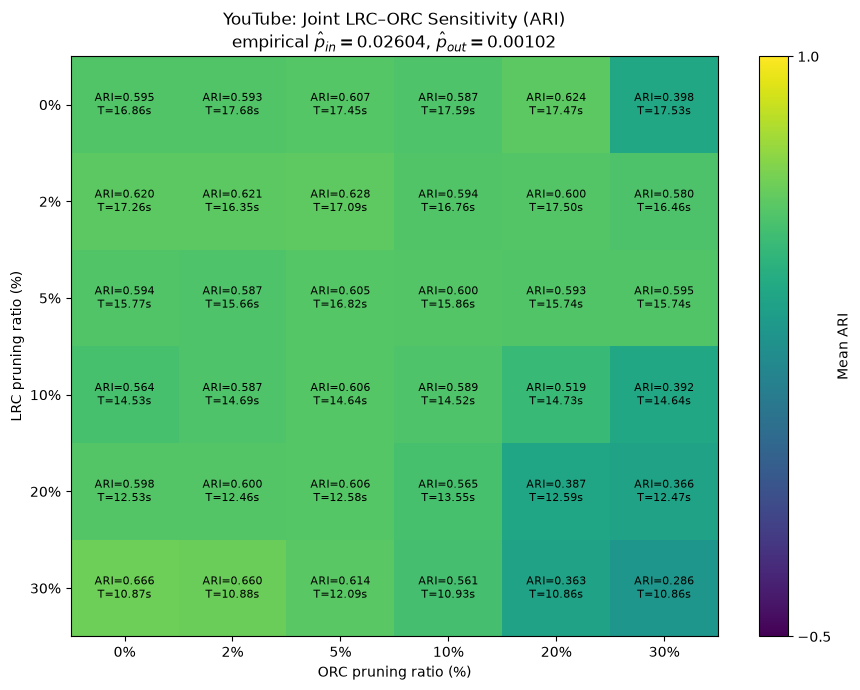

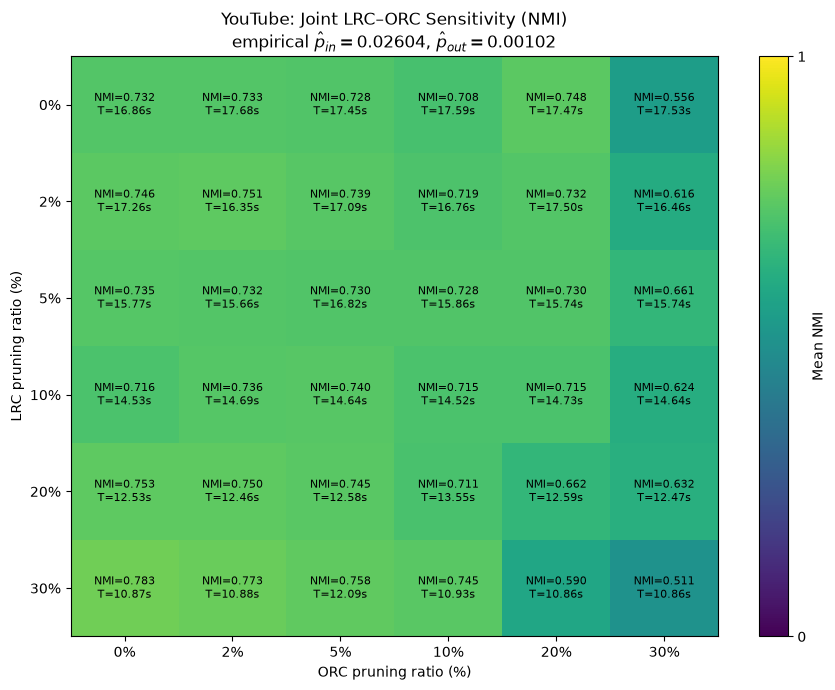


Saved:
  youtube_ari_lrc_orc_heatmap_with_runtime.png
  youtube_nmi_lrc_orc_heatmap_with_runtime.png
  youtube_lrc_orc_heatmap_summary.csv
  youtube_lrc_orc_heatmap_raw.csv
  youtube_empirical_pin_pout.csv


In [9]:
# ============================================================
# YOUTUBE: JOINT LRC-ORC PRUNING HEATMAPS
# Each cell shows accuracy + runtime
# p_in and p_out are estimated from the actual YouTube benchmark
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 0. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = Path(
    "./youtube_heatmaps"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. ESTIMATE EMPIRICAL p_in AND p_out
# ============================================================

def estimate_empirical_pin_pout(
    graph,
    label_attribute="label_gt",
):

    labeled_nodes = [
        node
        for node in graph.nodes()
        if label_attribute
        in graph.nodes[node]
    ]


    labels = {
        node:
            graph.nodes[node][
                label_attribute
            ]
        for node in labeled_nodes
    }


    # --------------------------------------------------------
    # Label sizes
    # --------------------------------------------------------

    label_counts = (
        pd.Series(
            list(
                labels.values()
            )
        )
        .value_counts()
        .to_dict()
    )


    # --------------------------------------------------------
    # Possible within-label pairs
    # --------------------------------------------------------

    possible_within = sum(
        n * (n - 1) / 2
        for n in label_counts.values()
    )


    total_nodes = len(
        labeled_nodes
    )


    possible_total = (
        total_nodes
        * (total_nodes - 1)
        / 2
    )


    possible_between = (
        possible_total
        - possible_within
    )


    # --------------------------------------------------------
    # Observed within/between edges
    # --------------------------------------------------------

    observed_within = 0
    observed_between = 0


    labeled_set = set(
        labeled_nodes
    )


    for u, v in graph.edges():

        if (
            u not in labeled_set
            or v not in labeled_set
        ):
            continue


        if labels[u] == labels[v]:

            observed_within += 1

        else:

            observed_between += 1


    # --------------------------------------------------------
    # Empirical p_in and p_out
    # --------------------------------------------------------

    p_in_hat = (
        observed_within
        / possible_within
        if possible_within > 0
        else np.nan
    )


    p_out_hat = (
        observed_between
        / possible_between
        if possible_between > 0
        else np.nan
    )


    return {

        "p_in":
            p_in_hat,

        "p_out":
            p_out_hat,

        "observed_within_edges":
            observed_within,

        "observed_between_edges":
            observed_between,

        "possible_within_pairs":
            possible_within,

        "possible_between_pairs":
            possible_between,

        "n_labeled":
            total_nodes,

        "n_labels":
            len(
                label_counts
            ),
    }


youtube_structure = (
    estimate_empirical_pin_pout(
        H,
        label_attribute="label_gt",
    )
)


YOUTUBE_PIN = (
    youtube_structure[
        "p_in"
    ]
)

YOUTUBE_POUT = (
    youtube_structure[
        "p_out"
    ]
)


print(
    "=" * 70
)

print(
    "YOUTUBE EMPIRICAL STRUCTURE"
)

print(
    "=" * 70
)


print(
    f"Nodes       : "
    f"{youtube_structure['n_labeled']}"
)

print(
    f"Labels      : "
    f"{youtube_structure['n_labels']}"
)

print(
    f"Within edges: "
    f"{youtube_structure['observed_within_edges']}"
)

print(
    f"Between edges: "
    f"{youtube_structure['observed_between_edges']}"
)

print(
    f"Estimated p_in  = "
    f"{YOUTUBE_PIN:.6f}"
)

print(
    f"Estimated p_out = "
    f"{YOUTUBE_POUT:.6f}"
)


# ============================================================
# 2. SENSITIVITY GRID
# ============================================================

# Includes the current 2% / 2% setting
LRC_HEAT_VALUES = [
    0,
    2,
    5,
    10,
    20,
    30,
]


ORC_HEAT_VALUES = [
    0,
    2,
    5,
    10,
    20,
    30,
]


HEATMAP_ALPHA = 0.5


HEATMAP_SEEDS = [
    0,
    1,
    2,
    3,
    4,
    42,
]


print(
    "\n"
    + "=" * 70
)

print(
    "YOUTUBE JOINT LRC-ORC SENSITIVITY"
)

print(
    "=" * 70
)

print(
    "LRC values:",
    LRC_HEAT_VALUES,
)

print(
    "ORC values:",
    ORC_HEAT_VALUES,
)

print(
    "alpha:",
    HEATMAP_ALPHA,
)

print(
    "seeds:",
    HEATMAP_SEEDS,
)


# ============================================================
# 3. RUN ALL PRUNING CONFIGURATIONS
# ============================================================

heatmap_rows = []


for lrc_pct in LRC_HEAT_VALUES:

    for orc_pct in ORC_HEAT_VALUES:

        print(
            f"\nRunning "
            f"LRC={lrc_pct}% | "
            f"ORC={orc_pct}% | "
            f"alpha={HEATMAP_ALPHA}"
        )


        # ----------------------------------------------------
        # Prepare graph once per grid cell
        # ----------------------------------------------------

        try:

            combo_info_heat = (
                cdu.prepare_combo_graph(
                    graph=H,
                    lrc_pct=lrc_pct,
                    orc_pct=orc_pct,
                    alpha=HEATMAP_ALPHA,
                    iterations=ORC_ITERATIONS,
                    method="Sinkhorn",
                    weight="weight",
                )
            )


        except Exception as error:

            print(
                "Preparation failed:",
                repr(error),
            )


            for seed in HEATMAP_SEEDS:

                heatmap_rows.append(
                    {
                        "seed":
                            seed,

                        "lrc_pct":
                            lrc_pct,

                        "orc_pct":
                            orc_pct,

                        "alpha":
                            HEATMAP_ALPHA,

                        "p_in":
                            YOUTUBE_PIN,

                        "p_out":
                            YOUTUBE_POUT,

                        "ARI":
                            np.nan,

                        "NMI":
                            np.nan,

                        "Runtime":
                            np.nan,

                        "Prep_time":
                            np.nan,

                        "Community_time":
                            np.nan,

                        "V":
                            np.nan,

                        "E":
                            np.nan,

                        "status":
                            "failed",
                    }
                )

            continue


        # ----------------------------------------------------
        # Evaluate Louvain across seeds
        # ----------------------------------------------------

        for seed in HEATMAP_SEEDS:

            result = (
                cdu.evaluate_prepared_graph(
                    info=combo_info_heat,
                    algorithm="louvain",
                    seed=seed,
                    weight="weight",
                    label_attribute="label_gt",
                )
            )


            heatmap_rows.append(
                {
                    "seed":
                        seed,

                    "lrc_pct":
                        lrc_pct,

                    "orc_pct":
                        orc_pct,

                    "alpha":
                        HEATMAP_ALPHA,

                    "p_in":
                        YOUTUBE_PIN,

                    "p_out":
                        YOUTUBE_POUT,

                    "ARI":
                        result[
                            "ARI"
                        ],

                    "NMI":
                        result[
                            "NMI"
                        ],

                    "Runtime":
                        result[
                            "runtime_sec"
                        ],

                    "Prep_time":
                        result[
                            "prep_time"
                        ],

                    "Community_time":
                        result[
                            "community_time"
                        ],

                    "V":
                        result[
                            "V"
                        ],

                    "E":
                        result[
                            "E"
                        ],

                    "status":
                        "ok",
                }
            )


df_youtube_heatmap_raw = (
    pd.DataFrame(
        heatmap_rows
    )
)


# ============================================================
# 4. SUMMARY ACROSS SEEDS
# ============================================================

df_youtube_heatmap_valid = (
    df_youtube_heatmap_raw[
        df_youtube_heatmap_raw[
            "status"
        ] == "ok"
    ]
    .copy()
)


youtube_heatmap_summary = (
    df_youtube_heatmap_valid
    .groupby(
        [
            "lrc_pct",
            "orc_pct",
        ],
        as_index=False,
    )
    .agg(

        ARI_mean=(
            "ARI",
            "mean",
        ),

        ARI_std=(
            "ARI",
            "std",
        ),

        NMI_mean=(
            "NMI",
            "mean",
        ),

        NMI_std=(
            "NMI",
            "std",
        ),

        Runtime_mean=(
            "Runtime",
            "mean",
        ),

        Runtime_std=(
            "Runtime",
            "std",
        ),

        Prep_time_mean=(
            "Prep_time",
            "mean",
        ),

        Community_time_mean=(
            "Community_time",
            "mean",
        ),

        V_mean=(
            "V",
            "mean",
        ),

        E_mean=(
            "E",
            "mean",
        ),
    )
)


print(
    "\nYouTube joint sensitivity summary:"
)

display(
    youtube_heatmap_summary
)


# ============================================================
# 5. BUILD HEATMAP MATRICES
# ============================================================

def make_heatmap_matrix(
    dataframe,
    value_column,
):

    return (
        dataframe
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values=value_column,
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )


ari_matrix = (
    make_heatmap_matrix(
        youtube_heatmap_summary,
        "ARI_mean",
    )
)


nmi_matrix = (
    make_heatmap_matrix(
        youtube_heatmap_summary,
        "NMI_mean",
    )
)


runtime_matrix = (
    make_heatmap_matrix(
        youtube_heatmap_summary,
        "Runtime_mean",
    )
)


# ============================================================
# 6. PLOT FUNCTION
#
# COLOR = ACCURACY
# CELL TEXT = ACCURACY + RUNTIME
# ============================================================

def plot_youtube_metric_heatmap(
    metric_matrix,
    runtime_matrix,
    metric_name,
):

    fig, ax = plt.subplots(
        figsize=(9, 7)
    )


    # --------------------------------------------------------
    # Metric-specific color scale
    # ARI: -0.5 to 1
    # NMI:  0 to 1
    # --------------------------------------------------------

    if metric_name == "ARI":

        vmin = -0.5
        vmax = 1.0

        colorbar_ticks = [
            -0.5,
            1.0,
        ]

    elif metric_name == "NMI":

        vmin = 0.0
        vmax = 1.0

        colorbar_ticks = [
            0.0,
            1.0,
        ]

    else:

        vmin = None
        vmax = None
        colorbar_ticks = None


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    im = ax.imshow(
        metric_matrix.values,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )


    # --------------------------------------------------------
    # X = ORC pruning
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(
                ORC_HEAT_VALUES
            )
        )
    )


    ax.set_xticklabels(
        [
            f"{value}%"
            for value
            in ORC_HEAT_VALUES
        ]
    )


    # --------------------------------------------------------
    # Y = LRC pruning
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(
                LRC_HEAT_VALUES
            )
        )
    )


    ax.set_yticklabels(
        [
            f"{value}%"
            for value
            in LRC_HEAT_VALUES
        ]
    )


    ax.set_xlabel(
        "ORC pruning ratio (%)"
    )


    ax.set_ylabel(
        "LRC pruning ratio (%)"
    )


    ax.set_title(
        f"YouTube: Joint LRC–ORC Sensitivity ({metric_name})\n"
        f"empirical "
        f"$\\hat{{p}}_{{in}}={YOUTUBE_PIN:.5f}$, "
        f"$\\hat{{p}}_{{out}}={YOUTUBE_POUT:.5f}$"
    )


    # --------------------------------------------------------
    # Cell annotation
    # --------------------------------------------------------

    for i, lrc_pct in enumerate(
        LRC_HEAT_VALUES
    ):

        for j, orc_pct in enumerate(
            ORC_HEAT_VALUES
        ):


            metric_value = (
                metric_matrix.loc[
                    lrc_pct,
                    orc_pct
                ]
            )


            runtime_value = (
                runtime_matrix.loc[
                    lrc_pct,
                    orc_pct
                ]
            )


            if (
                pd.isna(
                    metric_value
                )
                or pd.isna(
                    runtime_value
                )
            ):

                text = "failed"


            else:

                text = (
                    f"{metric_name}="
                    f"{metric_value:.3f}\n"
                    f"T="
                    f"{runtime_value:.2f}s"
                )


            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
            )


    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
    )


    if colorbar_ticks is not None:

        cbar.set_ticks(
            colorbar_ticks
        )


    cbar.set_label(
        f"Mean {metric_name}"
    )


    fig.tight_layout()

    return fig


# ============================================================
# 7. ARI HEATMAP
# ============================================================

fig_ari = (
    plot_youtube_metric_heatmap(
        metric_matrix=
            ari_matrix,

        runtime_matrix=
            runtime_matrix,

        metric_name=
            "ARI",
    )
)


plt.show()


# ============================================================
# 8. NMI HEATMAP
# ============================================================

fig_nmi = (
    plot_youtube_metric_heatmap(
        metric_matrix=
            nmi_matrix,

        runtime_matrix=
            runtime_matrix,

        metric_name=
            "NMI",
    )
)


plt.show()


# ============================================================
# 9. SAVE FIGURES + CSV FILES
# ============================================================

fig_ari.savefig(
    OUTPUT_DIR
    / "youtube_ari_lrc_orc_heatmap_with_runtime.png",
    dpi=300,
    bbox_inches="tight",
)


fig_nmi.savefig(
    OUTPUT_DIR
    / "youtube_nmi_lrc_orc_heatmap_with_runtime.png",
    dpi=300,
    bbox_inches="tight",
)


youtube_heatmap_summary.to_csv(
    OUTPUT_DIR
    / "youtube_lrc_orc_heatmap_summary.csv",
    index=False,
)


df_youtube_heatmap_raw.to_csv(
    OUTPUT_DIR
    / "youtube_lrc_orc_heatmap_raw.csv",
    index=False,
)


pd.DataFrame(
    [youtube_structure]
).to_csv(
    OUTPUT_DIR
    / "youtube_empirical_pin_pout.csv",
    index=False,
)


plt.close(
    fig_ari
)

plt.close(
    fig_nmi
)


print(
    "\nSaved:"
)

print(
    "  youtube_ari_lrc_orc_heatmap_with_runtime.png"
)

print(
    "  youtube_nmi_lrc_orc_heatmap_with_runtime.png"
)

print(
    "  youtube_lrc_orc_heatmap_summary.csv"
)

print(
    "  youtube_lrc_orc_heatmap_raw.csv"
)

print(
    "  youtube_empirical_pin_pout.csv"
)

In [10]:
# ============================================================
# 3. RUN FULL CURVATURE / PRUNING PIPELINE REPEATEDLY
#
# IMPORTANT:
# Runtime = ONLY preprocessing / pruning time
# Louvain community detection is NOT included in Runtime.
# ============================================================

heatmap_rows = []


for lrc_pct in LRC_HEAT_VALUES:

    for orc_pct in ORC_HEAT_VALUES:

        print("\n" + "-" * 70)

        print(
            f"LRC={lrc_pct}% | "
            f"ORC={orc_pct}% | "
            f"alpha={HEATMAP_ALPHA}"
        )

        print("-" * 70)


        for repeat in range(N_REPEATS):

            seed = LOUVAIN_SEEDS[
                repeat % len(LOUVAIN_SEEDS)
            ]


            print(
                f"  Repeat "
                f"{repeat + 1}/{N_REPEATS} "
                f"(seed={seed})"
            )


            try:

                # =================================================
                # START TIMER
                #
                # ONLY LRC + ORC / RICCI FLOW + PRUNING
                # =================================================

                pruning_start = time.perf_counter()


                combo_info_heat = (
                    cdu.prepare_combo_graph(
                        graph=H,
                        lrc_pct=lrc_pct,
                        orc_pct=orc_pct,
                        alpha=HEATMAP_ALPHA,
                        iterations=ORC_ITERATIONS,
                        method="Sinkhorn",
                        weight="weight",
                    )
                )


                pruning_runtime = (
                    time.perf_counter()
                    - pruning_start
                )


                # =================================================
                # STOP TIMER HERE
                #
                # Everything below is NOT included in Runtime.
                # =================================================


                # -------------------------------------------------
                # Community detection + ARI/NMI
                # -------------------------------------------------

                evaluation_start = time.perf_counter()


                result = (
                    cdu.evaluate_prepared_graph(
                        info=combo_info_heat,
                        algorithm="louvain",
                        seed=seed,
                        weight="weight",
                        label_attribute="label_gt",
                    )
                )


                evaluation_runtime = (
                    time.perf_counter()
                    - evaluation_start
                )


                # -------------------------------------------------
                # Save results
                # -------------------------------------------------

                heatmap_rows.append(
                    {

                        "repeat":
                            repeat,

                        "seed":
                            seed,

                        "lrc_pct":
                            lrc_pct,

                        "orc_pct":
                            orc_pct,

                        "alpha":
                            HEATMAP_ALPHA,

                        "p_in":
                            YOUTUBE_PIN,

                        "p_out":
                            YOUTUBE_POUT,

                        "ARI":
                            result["ARI"],

                        "NMI":
                            result["NMI"],


                        # =========================================
                        # THIS is the runtime shown in heatmap.
                        #
                        # Community detection is NOT included.
                        # =========================================

                        "Runtime":
                            pruning_runtime,


                        # -----------------------------------------
                        # Keep community time separately
                        # only for diagnostics.
                        # -----------------------------------------

                        "Community_time":
                            evaluation_runtime,


                        "V":
                            result["V"],

                        "E":
                            result["E"],

                        "status":
                            "ok",
                    }
                )


                print(
                    f"    ARI="
                    f"{result['ARI']:.3f} | "
                    f"NMI="
                    f"{result['NMI']:.3f} | "
                    f"Pruning="
                    f"{pruning_runtime:.2f}s | "
                    f"Community="
                    f"{evaluation_runtime:.2f}s"
                )


            except Exception as error:

                print(
                    "    FAILED:",
                    repr(error),
                )


                heatmap_rows.append(
                    {

                        "repeat":
                            repeat,

                        "seed":
                            seed,

                        "lrc_pct":
                            lrc_pct,

                        "orc_pct":
                            orc_pct,

                        "alpha":
                            HEATMAP_ALPHA,

                        "p_in":
                            YOUTUBE_PIN,

                        "p_out":
                            YOUTUBE_POUT,

                        "ARI":
                            np.nan,

                        "NMI":
                            np.nan,

                        "Runtime":
                            np.nan,

                        "Community_time":
                            np.nan,

                        "V":
                            np.nan,

                        "E":
                            np.nan,

                        "status":
                            "failed",
                    }
                )


# ============================================================
# 4. CREATE DATAFRAME
# ============================================================

df_youtube_heatmap_raw = pd.DataFrame(
    heatmap_rows
)


df_youtube_heatmap_valid = (
    df_youtube_heatmap_raw[
        df_youtube_heatmap_raw["status"] == "ok"
    ]
    .copy()
)


# ============================================================
# 5. SUMMARY ACROSS FULL INDEPENDENT RUNS
# ============================================================

youtube_heatmap_summary = (
    df_youtube_heatmap_valid
    .groupby(
        [
            "lrc_pct",
            "orc_pct",
        ],
        as_index=False,
    )
    .agg(

        ARI_mean=(
            "ARI",
            "mean",
        ),

        ARI_std=(
            "ARI",
            "std",
        ),

        NMI_mean=(
            "NMI",
            "mean",
        ),

        NMI_std=(
            "NMI",
            "std",
        ),


        # =========================================
        # PRUNING/PREPROCESSING TIME ONLY
        # =========================================

        Runtime_mean=(
            "Runtime",
            "mean",
        ),

        Runtime_std=(
            "Runtime",
            "std",
        ),


        # Community detection kept separately
        Community_time_mean=(
            "Community_time",
            "mean",
        ),

        Community_time_std=(
            "Community_time",
            "std",
        ),


        V_mean=(
            "V",
            "mean",
        ),

        E_mean=(
            "E",
            "mean",
        ),

        n_successful_runs=(
            "Runtime",
            "count",
        ),
    )
)


print(
    "\nYOUTUBE JOINT SENSITIVITY SUMMARY"
)

display(
    youtube_heatmap_summary
)


# ============================================================
# 6. CREATE HEATMAP MATRICES
# ============================================================

def make_heatmap_matrix(
    dataframe,
    value_column,
):

    return (
        dataframe
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values=value_column,
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )


ari_matrix = make_heatmap_matrix(
    youtube_heatmap_summary,
    "ARI_mean",
)


nmi_matrix = make_heatmap_matrix(
    youtube_heatmap_summary,
    "NMI_mean",
)


# ============================================================
# IMPORTANT:
# This matrix contains ONLY curvature/pruning preprocessing time
# ============================================================

runtime_matrix = make_heatmap_matrix(
    youtube_heatmap_summary,
    "Runtime_mean",
)


runtime_std_matrix = make_heatmap_matrix(
    youtube_heatmap_summary,
    "Runtime_std",
)


print(
    "\nPruning/preprocessing runtime matrix:"
)

display(
    runtime_matrix
)


print(
    "\nPruning/preprocessing runtime STD:"
)

display(
    runtime_std_matrix
)


----------------------------------------------------------------------
LRC=0% | ORC=0% | alpha=0.5
----------------------------------------------------------------------
  Repeat 1/5 (seed=0)
    ARI=0.621 | NMI=0.755 | Pruning=16.08s | Community=0.21s
  Repeat 2/5 (seed=1)
    ARI=0.615 | NMI=0.743 | Pruning=25.41s | Community=0.17s
  Repeat 3/5 (seed=2)
    ARI=0.579 | NMI=0.715 | Pruning=21.26s | Community=0.19s
  Repeat 4/5 (seed=3)
    ARI=0.564 | NMI=0.709 | Pruning=19.20s | Community=0.19s
  Repeat 5/5 (seed=4)
    ARI=0.581 | NMI=0.726 | Pruning=19.52s | Community=0.21s

----------------------------------------------------------------------
LRC=0% | ORC=2% | alpha=0.5
----------------------------------------------------------------------
  Repeat 1/5 (seed=0)
    ARI=0.617 | NMI=0.747 | Pruning=19.26s | Community=0.14s
  Repeat 2/5 (seed=1)
    ARI=0.626 | NMI=0.751 | Pruning=19.87s | Community=0.16s
  Repeat 3/5 (seed=2)
    ARI=0.574 | NMI=0.722 | Pruning=18.71s | Community=

,lrc_pct,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,Community_time_mean,Community_time_std,V_mean,E_mean,n_successful_runs
0,0,0,0.591860,0.024708,0.729768,1.921533e-02,20.294984,3.416118,0.195790,0.019388,1760.0,5600.0,5
1,0,2,0.591825,0.027361,0.733122,1.480192e-02,19.111815,0.473111,0.177432,0.043487,1760.0,5488.0,5
2,0,5,0.605309,0.020120,0.726646,1.070537e-02,19.210581,0.467232,0.162040,0.033493,1697.0,5253.0,5
3,0,10,0.589689,0.038777,0.709219,2.762785e-02,26.152833,1.596556,0.173588,0.024154,1692.0,4971.0,5
4,0,20,0.627498,0.006356,0.751108,3.361382e-03,23.547306,2.143389,0.125955,0.014271,1549.0,4263.0,5
5,0,30,0.406920,0.111570,0.558535,2.638788e-02,24.751164,2.742322,0.058204,0.020887,650.0,2202.0,5
6,2,0,0.617845,0.023182,0.744938,1.094852e-02,19.322648,0.383716,0.178992,0.032953,1760.0,5488.0,5
7,2,2,0.618517,0.028069,0.749675,1.456898e-02,20.468679,1.979765,0.196654,0.057790,1759.0,5378.0,5
8,2,5,0.625731,0.029764,0.739110,1.370921e-02,24.271376,3.392096,0.196156,0.028450,1697.0,5146.0,5
9,2,10,0.595067,0.016746,0.720009,9.440384e-03,25.446871,2.883322,0.189985,0.075267,1690.0,4869.0,5



Pruning/preprocessing runtime matrix:


orc_pct,0,2,5,10,20,30
lrc_pct,,,,,,
0,20.294984,19.111815,19.210581,26.152833,23.547306,24.751164
2,19.322648,20.468679,24.271376,25.446871,19.962356,19.175500
5,17.065728,17.658537,16.827324,17.694896,20.833790,16.455322
10,14.783473,12.669201,12.360613,11.974323,11.538507,11.247091
20,9.288336,9.793683,8.182937,8.153978,5.904081,7.223897
30,5.575341,4.417067,6.714239,7.118106,7.087674,7.329411



Pruning/preprocessing runtime STD:


orc_pct,0,2,5,10,20,30
lrc_pct,,,,,,
0,3.416118,0.473111,0.467232,1.596556,2.143389,2.742322
2,0.383716,1.979765,3.392096,2.883322,1.175471,1.240499
5,0.152333,0.725735,0.443768,2.696314,3.839188,0.828242
10,1.076834,0.513436,0.337324,0.647099,0.406151,0.734683
20,0.497735,0.832960,0.103954,0.313429,1.235634,2.478196
30,0.974977,0.167652,1.676999,0.258065,0.075990,0.431967



------------------------------------------------------------
LRC=0% | ORC=0% | alpha=0.5
------------------------------------------------------------
Seed=0 | ARI=0.621 | NMI=0.755 | T=7.36s
Seed=1 | ARI=0.615 | NMI=0.743 | T=7.15s

------------------------------------------------------------
LRC=0% | ORC=5% | alpha=0.5
------------------------------------------------------------
Seed=0 | ARI=0.607 | NMI=0.737 | T=7.50s
Seed=1 | ARI=0.589 | NMI=0.720 | T=7.25s

------------------------------------------------------------
LRC=0% | ORC=10% | alpha=0.5
------------------------------------------------------------
Seed=0 | ARI=0.637 | NMI=0.743 | T=7.17s
Seed=1 | ARI=0.536 | NMI=0.674 | T=7.21s

------------------------------------------------------------
LRC=0% | ORC=15% | alpha=0.5
------------------------------------------------------------
Seed=0 | ARI=0.583 | NMI=0.709 | T=7.24s
Seed=1 | ARI=0.610 | NMI=0.738 | T=7.26s

------------------------------------------------------------
LRC=

,lrc_pct,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,E_mean
0,0,0,0.617794,0.004065,0.749135,0.008069,7.254247,0.150790,1760.0,5600.0
1,0,5,0.598464,0.012766,0.728655,0.012434,7.376346,0.176117,1697.0,5253.0
2,0,10,0.586872,0.071530,0.708556,0.048720,7.192027,0.030127,1692.0,4971.0
3,0,15,0.596744,0.018868,0.723325,0.020812,7.254106,0.013591,1635.0,4651.0
4,0,20,0.628793,0.004165,0.750924,0.005183,7.327871,0.041179,1549.0,4263.0
5,0,25,0.627309,0.003770,0.733752,0.001519,7.397034,0.045503,1278.0,3549.0
6,5,0,0.586327,0.059935,0.730922,0.022037,6.808573,0.000372,1760.0,5320.0
7,5,5,0.608694,0.017655,0.735422,0.013693,7.059059,0.330265,1696.0,4987.0
8,5,10,0.599811,0.004692,0.725367,0.005869,6.874507,0.030967,1691.0,4719.0
9,5,15,0.584881,0.001526,0.733023,0.006593,6.863645,0.035200,1656.0,4430.0


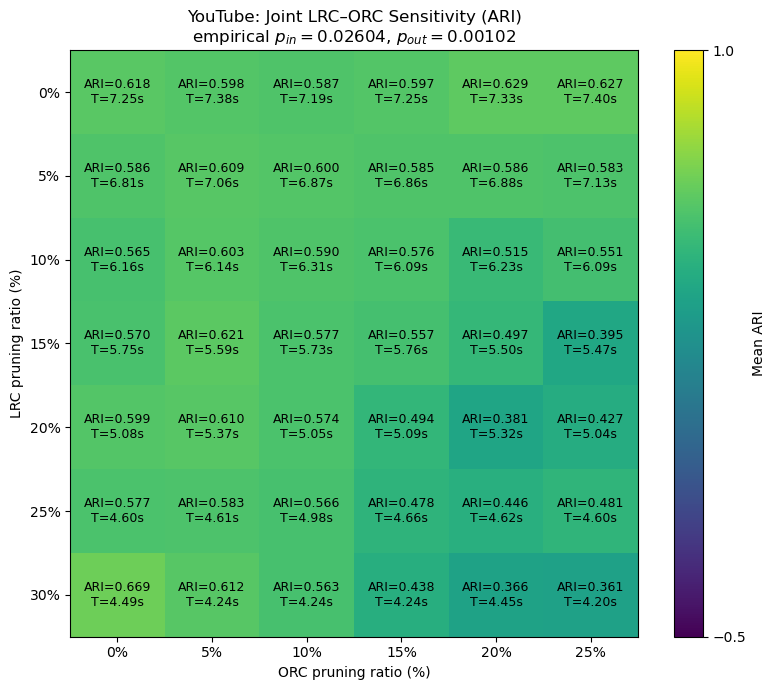

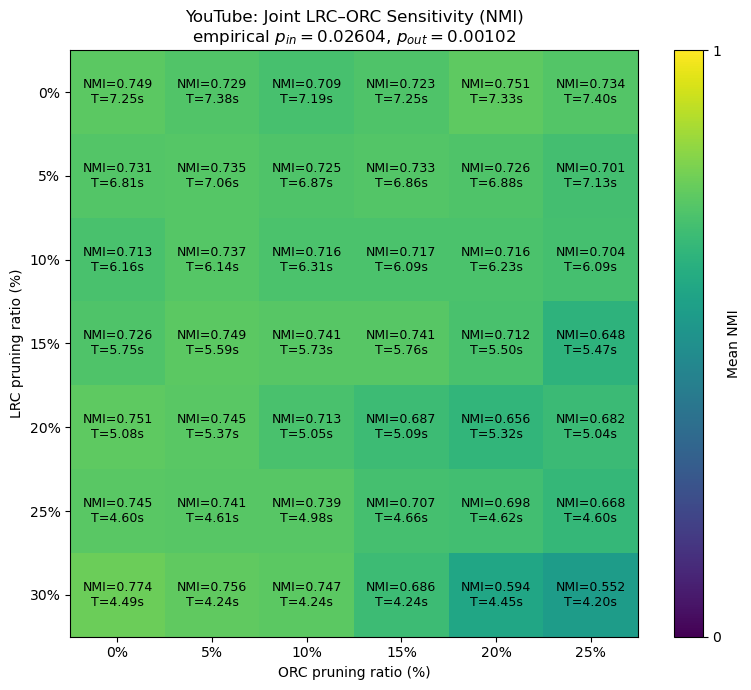

In [18]:
# ============================================================
# YOUTUBE: QUICK LRC–ORC SENSITIVITY
#
# LRC pruning: [0, 5, 10, 15, 20, 25, 30]
# ORC pruning: [0, 5, 10]
#
# Only 2 seeds to reduce runtime
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. SETTINGS
# ============================================================

LRC_HEAT_VALUES = [
    0, 5, 10, 15, 20, 25, 30
]

ORC_HEAT_VALUES = [
    0, 5, 10, 15, 20, 25
]


HEATMAP_ALPHA = 0.5


# ------------------------------------------------------------
# Keep the experiment short
# ------------------------------------------------------------

LOUVAIN_SEEDS = [0, 1]

N_REPEATS = 2


# ============================================================
# 2. RUN EXPERIMENT
# ============================================================

heatmap_rows = []


for lrc_pct in LRC_HEAT_VALUES:

    for orc_pct in ORC_HEAT_VALUES:

        print("\n" + "-" * 60)

        print(
            f"LRC={lrc_pct}% | "
            f"ORC={orc_pct}% | "
            f"alpha={HEATMAP_ALPHA}"
        )

        print("-" * 60)


        for repeat in range(N_REPEATS):

            seed = LOUVAIN_SEEDS[repeat]


            try:

                # ==============================================
                # PREPROCESSING TIMER START
                # ==============================================

                pruning_start = time.perf_counter()


                combo_info_heat = (
                    cdu.prepare_combo_graph(
                        graph=H,
                        lrc_pct=lrc_pct,
                        orc_pct=orc_pct,
                        alpha=HEATMAP_ALPHA,
                        iterations=ORC_ITERATIONS,
                        method="Sinkhorn",
                        weight="weight",
                    )
                )


                pruning_runtime = (
                    time.perf_counter()
                    - pruning_start
                )


                # ==============================================
                # TIMER STOPS BEFORE COMMUNITY DETECTION
                # ==============================================


                result = (
                    cdu.evaluate_prepared_graph(
                        info=combo_info_heat,
                        algorithm="louvain",
                        seed=seed,
                        weight="weight",
                        label_attribute="label_gt",
                    )
                )


                heatmap_rows.append(
                    {
                        "repeat": repeat,
                        "seed": seed,

                        "lrc_pct": lrc_pct,
                        "orc_pct": orc_pct,

                        "alpha": HEATMAP_ALPHA,

                        "ARI": result["ARI"],
                        "NMI": result["NMI"],

                        # preprocessing only
                        "Runtime": pruning_runtime,

                        "V": result["V"],
                        "E": result["E"],

                        "status": "ok",
                    }
                )


                print(
                    f"Seed={seed} | "
                    f"ARI={result['ARI']:.3f} | "
                    f"NMI={result['NMI']:.3f} | "
                    f"T={pruning_runtime:.2f}s"
                )


            except Exception as error:

                print(
                    "FAILED:",
                    repr(error)
                )


                heatmap_rows.append(
                    {
                        "repeat": repeat,
                        "seed": seed,

                        "lrc_pct": lrc_pct,
                        "orc_pct": orc_pct,

                        "alpha": HEATMAP_ALPHA,

                        "ARI": np.nan,
                        "NMI": np.nan,
                        "Runtime": np.nan,

                        "V": np.nan,
                        "E": np.nan,

                        "status": "failed",
                    }
                )


# ============================================================
# 3. DATAFRAME
# ============================================================

df_heatmap_raw = pd.DataFrame(
    heatmap_rows
)


df_heatmap_valid = (
    df_heatmap_raw[
        df_heatmap_raw["status"] == "ok"
    ]
    .copy()
)


# ============================================================
# 4. SUMMARY
# ============================================================

youtube_heatmap_summary = (
    df_heatmap_valid
    .groupby(
        [
            "lrc_pct",
            "orc_pct",
        ],
        as_index=False,
    )
    .agg(

        ARI_mean=(
            "ARI",
            "mean"
        ),

        ARI_std=(
            "ARI",
            "std"
        ),

        NMI_mean=(
            "NMI",
            "mean"
        ),

        NMI_std=(
            "NMI",
            "std"
        ),

        Runtime_mean=(
            "Runtime",
            "mean"
        ),

        Runtime_std=(
            "Runtime",
            "std"
        ),

        V_mean=(
            "V",
            "mean"
        ),

        E_mean=(
            "E",
            "mean"
        ),
    )
)


display(
    youtube_heatmap_summary
)


# ============================================================
# 5. CREATE MATRICES
# ============================================================

def make_matrix(
    column
):

    return (
        youtube_heatmap_summary
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values=column,
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )


ari_matrix = make_matrix(
    "ARI_mean"
)

nmi_matrix = make_matrix(
    "NMI_mean"
)

runtime_matrix = make_matrix(
    "Runtime_mean"
)


# ============================================================
# 6. HEATMAP FUNCTION
# ============================================================

def plot_youtube_heatmap(
    metric_matrix,
    runtime_matrix,
    metric_name,
):

    # --------------------------------------------------------
    # Same color scales as your current figures
    # --------------------------------------------------------

    if metric_name == "ARI":

        vmin = -0.5
        vmax = 1

        colorbar_ticks = [
            -0.5,
            1
        ]

    else:

        vmin = 0
        vmax = 1

        colorbar_ticks = [
            0,
            1
        ]


    fig, ax = plt.subplots(
        figsize=(8, 7)
    )


    im = ax.imshow(
        metric_matrix.values,
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )


    # --------------------------------------------------------
    # AXES
    # --------------------------------------------------------

    ax.set_xticks(
        range(
            len(ORC_HEAT_VALUES)
        )
    )

    ax.set_xticklabels(
        [
            f"{x}%"
            for x in ORC_HEAT_VALUES
        ]
    )


    ax.set_yticks(
        range(
            len(LRC_HEAT_VALUES)
        )
    )

    ax.set_yticklabels(
        [
            f"{x}%"
            for x in LRC_HEAT_VALUES
        ]
    )


    ax.set_xlabel(
        "ORC pruning ratio (%)"
    )

    ax.set_ylabel(
        "LRC pruning ratio (%)"
    )


    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    ax.set_title(
        f"YouTube: Joint LRC–ORC Sensitivity ({metric_name})\n"
        rf"empirical $p_{{in}}={YOUTUBE_PIN:.5f}$, "
        rf"$p_{{out}}={YOUTUBE_POUT:.5f}$"
    )


    # --------------------------------------------------------
    # WRITE METRIC + RUNTIME IN EACH CELL
    # --------------------------------------------------------

    for i in range(
        len(LRC_HEAT_VALUES)
    ):

        for j in range(
            len(ORC_HEAT_VALUES)
        ):

            value = (
                metric_matrix.iloc[i, j]
            )

            runtime = (
                runtime_matrix.iloc[i, j]
            )


            if (
                np.isfinite(value)
                and np.isfinite(runtime)
            ):

                ax.text(
                    j,
                    i,

                    f"{metric_name}="
                    f"{value:.3f}\n"
                    f"T={runtime:.2f}s",

                    ha="center",
                    va="center",

                    fontsize=9,
                )


    # --------------------------------------------------------
    # COLORBAR
    # --------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
    )

    cbar.set_label(
        f"Mean {metric_name}"
    )

    cbar.set_ticks(
        colorbar_ticks
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 7. ARI HEATMAP
# ============================================================

plot_youtube_heatmap(
    ari_matrix,
    runtime_matrix,
    "ARI",
)


# ============================================================
# 8. NMI HEATMAP
# ============================================================

plot_youtube_heatmap(
    nmi_matrix,
    runtime_matrix,
    "NMI",
)


------------------------------------------------------------
LRC=0% | ORC=0% | alpha=0.5
------------------------------------------------------------
Seed=0 | ARI=0.621 | NMI=0.755 | Total T=7.70s
Seed=1 | ARI=0.615 | NMI=0.743 | Total T=7.41s

------------------------------------------------------------
LRC=0% | ORC=5% | alpha=0.5
------------------------------------------------------------
Seed=0 | ARI=0.607 | NMI=0.737 | Total T=7.43s
Seed=1 | ARI=0.589 | NMI=0.720 | Total T=7.48s

------------------------------------------------------------
LRC=0% | ORC=10% | alpha=0.5
------------------------------------------------------------
Seed=0 | ARI=0.637 | NMI=0.743 | Total T=7.80s
Seed=1 | ARI=0.536 | NMI=0.674 | Total T=7.55s

------------------------------------------------------------
LRC=0% | ORC=15% | alpha=0.5
------------------------------------------------------------
Seed=0 | ARI=0.583 | NMI=0.709 | Total T=7.59s
Seed=1 | ARI=0.610 | NMI=0.738 | Total T=7.61s

-----------------

,lrc_pct,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,E_mean
0,0,0,0.617794,0.004065,0.749135,0.008069,7.552963,0.207679,1760.0,5600.0
1,0,5,0.598464,0.012766,0.728655,0.012434,7.458298,0.034117,1697.0,5253.0
2,0,10,0.586872,0.071530,0.708556,0.048720,7.678224,0.175296,1692.0,4971.0
3,0,15,0.596744,0.018868,0.723325,0.020812,7.600118,0.009115,1635.0,4651.0
4,0,20,0.628793,0.004165,0.750924,0.005183,7.522501,0.059260,1549.0,4263.0
5,0,25,0.627309,0.003770,0.733752,0.001519,7.737434,0.391785,1278.0,3549.0
6,5,0,0.586327,0.059935,0.730922,0.022037,6.893901,0.059460,1760.0,5320.0
7,5,5,0.608694,0.017655,0.735422,0.013693,6.932955,0.053696,1696.0,4987.0
8,5,10,0.599811,0.004692,0.725367,0.005869,7.024065,0.294957,1691.0,4719.0
9,5,15,0.584881,0.001526,0.733023,0.006593,6.845786,0.017733,1656.0,4430.0


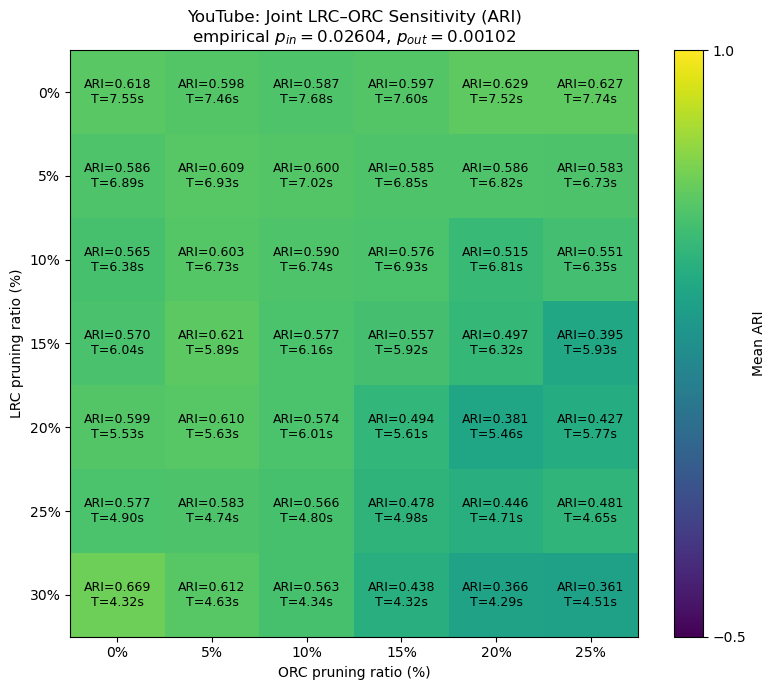

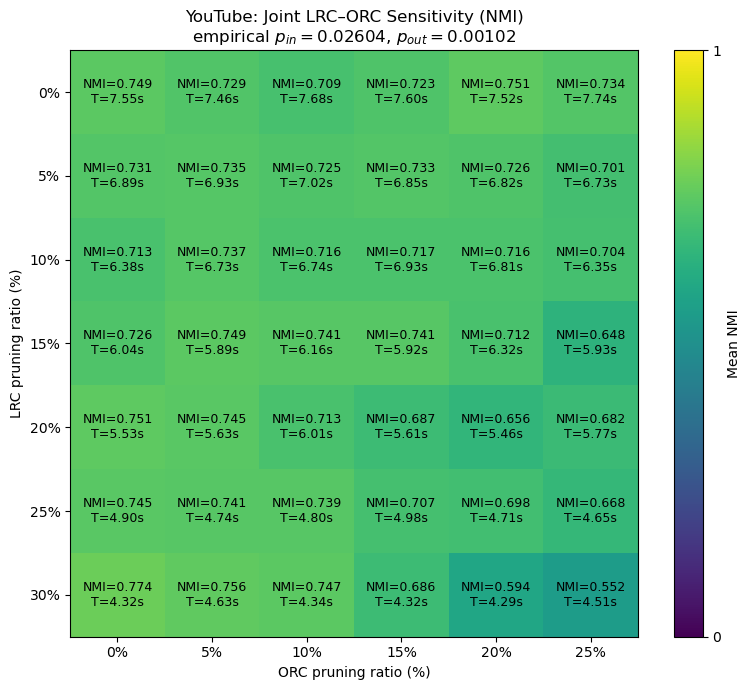

In [20]:
# ============================================================
# YOUTUBE: LRC–ORC SENSITIVITY
#
# Runtime includes:
# LRC + pruning + ORC/Ricci Flow + ORC pruning
# + Louvain community detection
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. SETTINGS
# ============================================================

LRC_HEAT_VALUES = [
    0, 5, 10, 15, 20, 25, 30
]

ORC_HEAT_VALUES = [
    0, 5, 10, 15, 20, 25
]

HEATMAP_ALPHA = 0.5


# Fewer seeds for faster execution
LOUVAIN_SEEDS = [0, 1]

N_REPEATS = 2


# ============================================================
# 2. RUN EXPERIMENT
# ============================================================

heatmap_rows = []


for lrc_pct in LRC_HEAT_VALUES:

    for orc_pct in ORC_HEAT_VALUES:

        print("\n" + "-" * 60)

        print(
            f"LRC={lrc_pct}% | "
            f"ORC={orc_pct}% | "
            f"alpha={HEATMAP_ALPHA}"
        )

        print("-" * 60)


        for repeat in range(N_REPEATS):

            seed = LOUVAIN_SEEDS[repeat]


            try:

                # ==============================================
                # TOTAL TIMER START
                # ==============================================

                total_start = time.perf_counter()


                # ----------------------------------------------
                # Preprocessing
                # ----------------------------------------------

                combo_info_heat = (
                    cdu.prepare_combo_graph(
                        graph=H,
                        lrc_pct=lrc_pct,
                        orc_pct=orc_pct,
                        alpha=HEATMAP_ALPHA,
                        iterations=ORC_ITERATIONS,
                        method="Sinkhorn",
                        weight="weight",
                    )
                )


                # ----------------------------------------------
                # Community detection
                # ----------------------------------------------

                result = (
                    cdu.evaluate_prepared_graph(
                        info=combo_info_heat,
                        algorithm="louvain",
                        seed=seed,
                        weight="weight",
                        label_attribute="label_gt",
                    )
                )


                # ==============================================
                # TOTAL TIMER STOP
                # ==============================================

                total_runtime = (
                    time.perf_counter()
                    - total_start
                )


                heatmap_rows.append(
                    {
                        "repeat": repeat,
                        "seed": seed,

                        "lrc_pct": lrc_pct,
                        "orc_pct": orc_pct,

                        "alpha": HEATMAP_ALPHA,

                        "ARI": result["ARI"],
                        "NMI": result["NMI"],

                        # TOTAL:
                        # preprocessing + community detection
                        "Runtime": total_runtime,

                        "V": result["V"],
                        "E": result["E"],

                        "status": "ok",
                    }
                )


                print(
                    f"Seed={seed} | "
                    f"ARI={result['ARI']:.3f} | "
                    f"NMI={result['NMI']:.3f} | "
                    f"Total T={total_runtime:.2f}s"
                )


            except Exception as error:

                print(
                    "FAILED:",
                    repr(error)
                )


                heatmap_rows.append(
                    {
                        "repeat": repeat,
                        "seed": seed,

                        "lrc_pct": lrc_pct,
                        "orc_pct": orc_pct,

                        "alpha": HEATMAP_ALPHA,

                        "ARI": np.nan,
                        "NMI": np.nan,
                        "Runtime": np.nan,

                        "V": np.nan,
                        "E": np.nan,

                        "status": "failed",
                    }
                )


# ============================================================
# 3. DATAFRAME
# ============================================================

df_heatmap_raw = pd.DataFrame(
    heatmap_rows
)


df_heatmap_valid = (
    df_heatmap_raw[
        df_heatmap_raw["status"] == "ok"
    ]
    .copy()
)


# ============================================================
# 4. SUMMARY
# ============================================================

youtube_heatmap_summary = (
    df_heatmap_valid
    .groupby(
        [
            "lrc_pct",
            "orc_pct",
        ],
        as_index=False,
    )
    .agg(

        ARI_mean=(
            "ARI",
            "mean"
        ),

        ARI_std=(
            "ARI",
            "std"
        ),

        NMI_mean=(
            "NMI",
            "mean"
        ),

        NMI_std=(
            "NMI",
            "std"
        ),

        Runtime_mean=(
            "Runtime",
            "mean"
        ),

        Runtime_std=(
            "Runtime",
            "std"
        ),

        V_mean=(
            "V",
            "mean"
        ),

        E_mean=(
            "E",
            "mean"
        ),
    )
)


display(
    youtube_heatmap_summary
)


# ============================================================
# 5. MATRICES
# ============================================================

def make_matrix(
    column
):

    return (
        youtube_heatmap_summary
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values=column,
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )


ari_matrix = make_matrix(
    "ARI_mean"
)

nmi_matrix = make_matrix(
    "NMI_mean"
)

runtime_matrix = make_matrix(
    "Runtime_mean"
)


# ============================================================
# 6. HEATMAP
# ============================================================

def plot_youtube_heatmap(
    metric_matrix,
    runtime_matrix,
    metric_name,
):

    if metric_name == "ARI":

        vmin = -0.5
        vmax = 1

        colorbar_ticks = [
            -0.5,
            1
        ]

    else:

        vmin = 0
        vmax = 1

        colorbar_ticks = [
            0,
            1
        ]


    fig, ax = plt.subplots(
        figsize=(8, 7)
    )


    im = ax.imshow(
        metric_matrix.values,
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )


    ax.set_xticks(
        range(
            len(ORC_HEAT_VALUES)
        )
    )

    ax.set_xticklabels(
        [
            f"{x}%"
            for x in ORC_HEAT_VALUES
        ]
    )


    ax.set_yticks(
        range(
            len(LRC_HEAT_VALUES)
        )
    )

    ax.set_yticklabels(
        [
            f"{x}%"
            for x in LRC_HEAT_VALUES
        ]
    )


    ax.set_xlabel(
        "ORC pruning ratio (%)"
    )

    ax.set_ylabel(
        "LRC pruning ratio (%)"
    )


    ax.set_title(
        f"YouTube: Joint LRC–ORC Sensitivity ({metric_name})\n"
        rf"empirical $p_{{in}}={YOUTUBE_PIN:.5f}$, "
        rf"$p_{{out}}={YOUTUBE_POUT:.5f}$"
    )


    for i in range(
        len(LRC_HEAT_VALUES)
    ):

        for j in range(
            len(ORC_HEAT_VALUES)
        ):

            value = (
                metric_matrix.iloc[i, j]
            )

            runtime = (
                runtime_matrix.iloc[i, j]
            )


            if (
                np.isfinite(value)
                and np.isfinite(runtime)
            ):

                ax.text(
                    j,
                    i,

                    f"{metric_name}="
                    f"{value:.3f}\n"
                    f"T={runtime:.2f}s",

                    ha="center",
                    va="center",

                    fontsize=9,
                )


    cbar = fig.colorbar(
        im,
        ax=ax,
    )

    cbar.set_label(
        f"Mean {metric_name}"
    )

    cbar.set_ticks(
        colorbar_ticks
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 7. PLOTS
# ============================================================

plot_youtube_heatmap(
    ari_matrix,
    runtime_matrix,
    "ARI",
)


plot_youtube_heatmap(
    nmi_matrix,
    runtime_matrix,
    "NMI",
)


YouTube
empirical p_in  = 0.026038
empirical p_out = 0.001021

YouTube | LRC=0% | ORC=0%
seed=0 | ARI=0.621 | NMI=0.755 | T=19.54s
seed=1 | ARI=0.615 | NMI=0.743 | T=19.52s

YouTube | LRC=0% | ORC=5%
seed=0 | ARI=0.607 | NMI=0.737 | T=22.37s
seed=1 | ARI=0.589 | NMI=0.720 | T=22.29s

YouTube | LRC=0% | ORC=10%
seed=0 | ARI=0.637 | NMI=0.743 | T=27.24s
seed=1 | ARI=0.536 | NMI=0.674 | T=27.20s

YouTube | LRC=0% | ORC=20%
seed=0 | ARI=0.632 | NMI=0.755 | T=20.14s
seed=1 | ARI=0.626 | NMI=0.747 | T=20.23s

YouTube | LRC=0% | ORC=30%
seed=0 | ARI=0.362 | NMI=0.554 | T=14.66s
seed=1 | ARI=0.606 | NMI=0.605 | T=14.67s

YouTube | LRC=5% | ORC=0%
seed=0 | ARI=0.629 | NMI=0.747 | T=17.00s
seed=1 | ARI=0.544 | NMI=0.715 | T=17.18s

YouTube | LRC=5% | ORC=5%
seed=0 | ARI=0.621 | NMI=0.745 | T=15.30s
seed=1 | ARI=0.596 | NMI=0.726 | T=15.77s

YouTube | LRC=5% | ORC=10%
seed=0 | ARI=0.603 | NMI=0.721 | T=16.61s
seed=1 | ARI=0.596 | NMI=0.730 | T=16.72s

YouTube | LRC=5% | ORC=20%
seed=0 | ARI=0.61

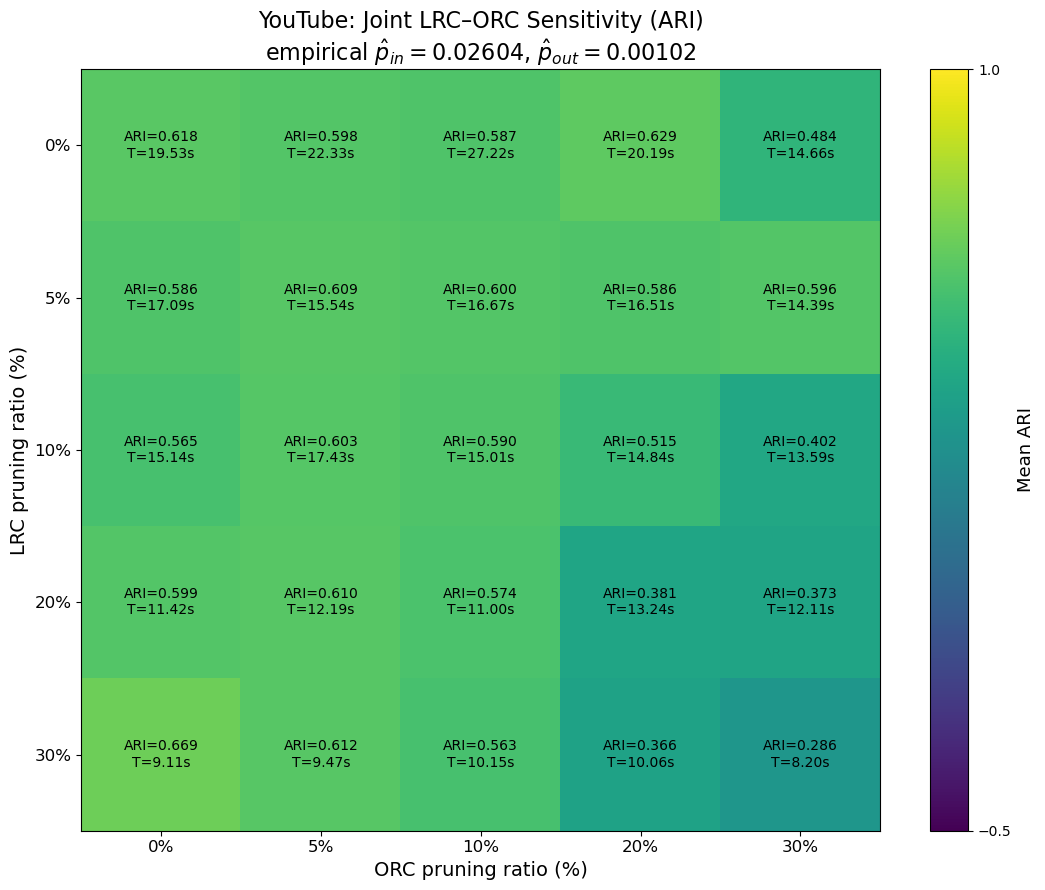

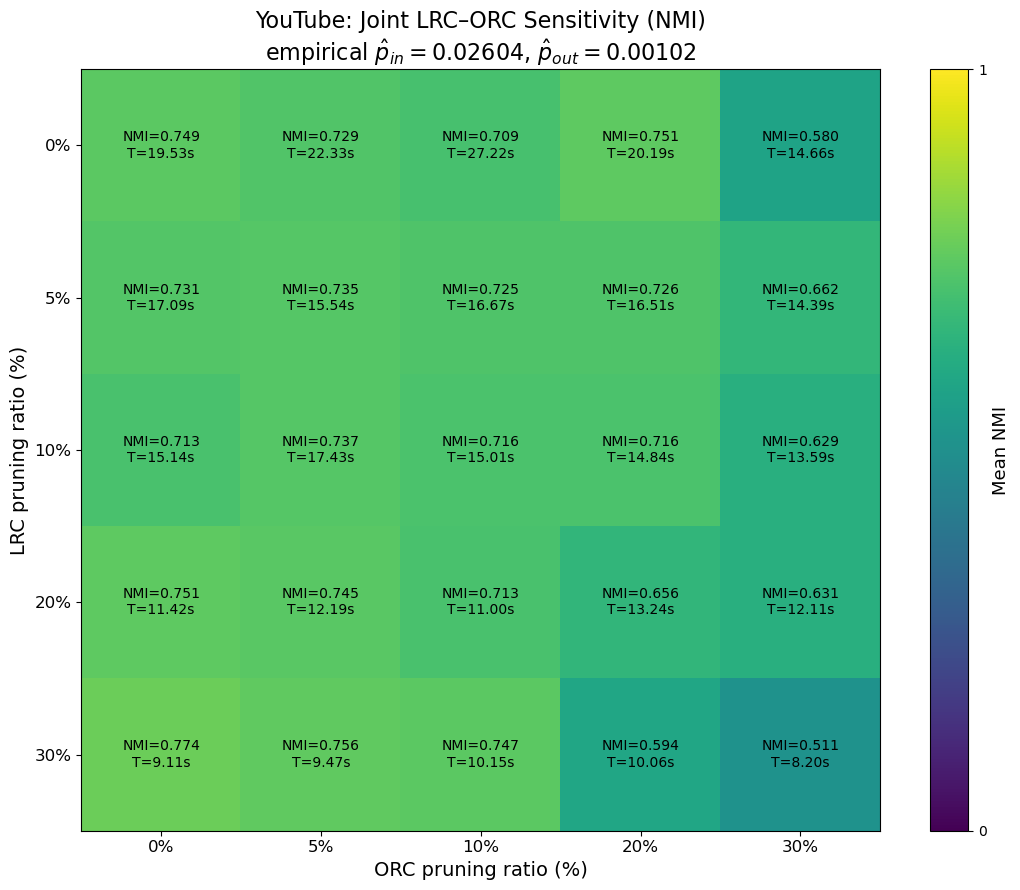

In [22]:
import importlib
import community_detection_utils as cdu

importlib.reload(cdu)
youtube_raw, youtube_summary = cdu.run_real_dataset_heatmap(
    H,
    "YouTube",
    orc_iterations=5
)